# 🤖⚡ NeurOGrasp: Neuromorphic Transparent Object Grasping
## Complete Step-by-Step Guide | Spiking Neural Networks + Event Camera + Robot Simulation

---

### 📋 What This Notebook Covers

| Step | Topic | What You Learn |
|------|-------|----------------|
| 1 | Setup | Install all dependencies |
| 2 | Problem | Why cameras fail on glass |
| 3 | Dataset | Synthetic scene generation |
| 4 | Event Camera | v2e simulation — frames → events |
| 5 | Voxel Grid | Events → fixed tensor |
| 6 | SNN Architecture | LIF neurons, surrogate gradients |
| 7 | Temporal Attention | Which time bins matter |
| 8 | Detection Heads | BBox, Confidence, Class, Grasp |
| 9 | Loss Functions | SmoothL1, BCE, CrossEntropy |
| 10 | Training | AdamW, cosine LR, early stopping |
| 11 | Inference | End-to-end pipeline |
| 12 | Results | Visualisations and metrics |
| 13 | Ablation | Component importance |

> **Runtime**: `Runtime → Change runtime type → T4 GPU` for 5× faster training (optional)
> **Time**: ~25 minutes on CPU, ~8 minutes on GPU


---
## Step 1: Install Dependencies

We need PyTorch, OpenCV, and matplotlib. SpikingJelly is optional (we have a fallback).


In [ ]:
%%capture
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118 -q
!pip install opencv-python-headless matplotlib tqdm numpy -q
!pip install spikingjelly -q 2>/dev/null || echo "SpikingJelly optional - using built-in LIF"


In [ ]:
import torch
import numpy as np
import cv2
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print("=" * 55)
print("  NeurOGrasp Environment Check")
print("=" * 55)
print(f"  PyTorch version  : {torch.__version__}")
print(f"  Device           : {device}")
if torch.cuda.is_available():
    print(f"  GPU              : {torch.cuda.get_device_name(0)}")
    print(f"  VRAM             : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")
print(f"  NumPy version    : {np.__version__}")
print(f"  OpenCV version   : {cv2.__version__}")
print("=" * 55)
print("✅ Ready to build NeurOGrasp!")


  NeurOGrasp Environment Check
  PyTorch version  : 2.10.0+cu128
  Device           : cuda
  GPU              : Tesla T4
  VRAM             : 15.6 GB
  NumPy version    : 2.0.2
  OpenCV version   : 4.13.0
✅ Ready to build NeurOGrasp!


---
## Step 2: The Problem — Why Cameras Fail on Glass 🔍

Before writing any code, understand **why** this project exists.

### Conventional RGB-D Camera
- Measures absolute **colour** (RGB) and **depth** (infrared)
- Glass is **transparent** → infrared passes through → depth sensor sees the table, not the bottle
- Colour camera sees the background through the glass
- Result: robot thinks the glass bottle doesn't exist

### Our Solution: Event Camera (DVS)
- Fires events only when **brightness changes** at a pixel
- When glass **moves**, it bends light (refraction) → background pixels shift → events fire!
- Glass edges become clearly visible as bursts of events
- Even though glass is invisible to colour cameras, it generates distinctive events

### Key Insight
```
Normal camera  →  sees WHAT is there (colour/depth)
Event camera   →  sees WHAT CHANGED  (temporal brightness gradients)
```
Glass bends light as it moves → **the bending is visible as change** → events fire around glass edges


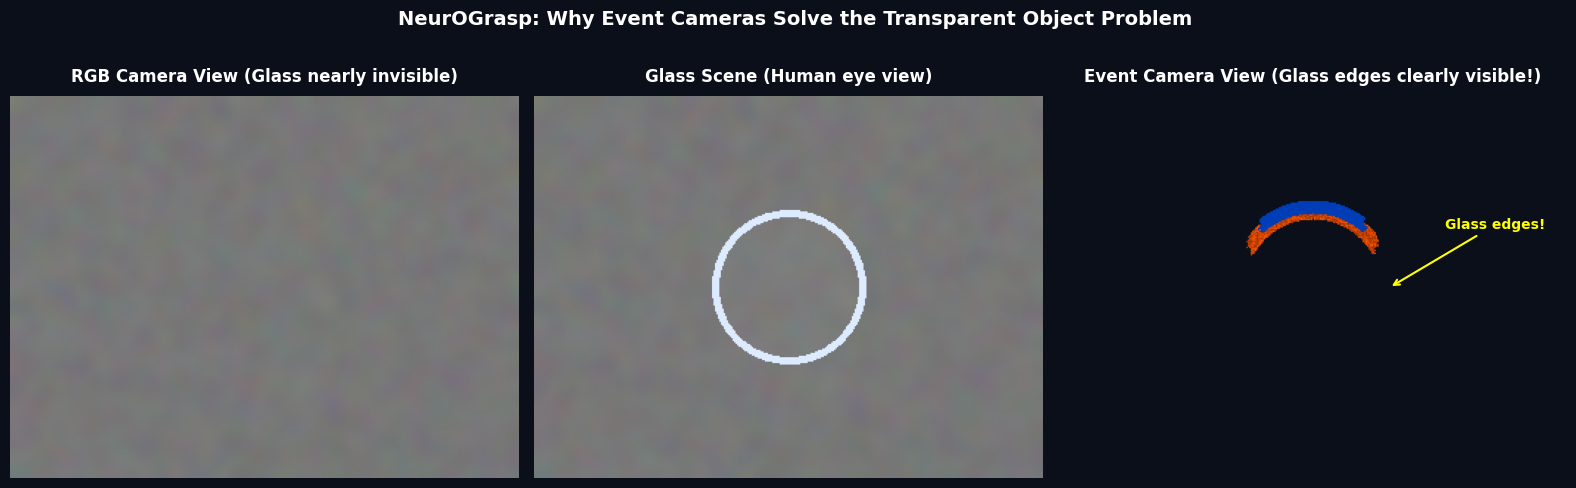

Key insight: Glass that is invisible to RGB cameras
generates CLEAR signals in event cameras due to refraction!


In [ ]:
# ── Visualise the problem ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.patch.set_facecolor('#0a0f1a')

np.random.seed(42)
H, W = 260, 346

# 1. Background (what a camera sees)
bg = np.random.randint(60, 180, (H, W, 3), dtype=np.uint8)
bg = cv2.GaussianBlur(bg, (21, 21), 5)

# 2. Glass scene — nearly invisible
glass_scene = bg.copy().astype(np.float32)
mask = np.zeros((H, W), dtype=np.float32)
cv2.circle(mask, (W//2, H//2), 50, 1.0, -1)
for ch in range(3):
    glass_scene[:,:,ch] = np.where(mask>0, glass_scene[:,:,ch]*0.95+10, glass_scene[:,:,ch])
edge = np.zeros_like(mask)
cv2.circle(edge, (W//2, H//2), 50, 1.0, 3)
glass_scene[:,:,0] = np.where(edge>0, 220, glass_scene[:,:,0])
glass_scene[:,:,1] = np.where(edge>0, 235, glass_scene[:,:,1])
glass_scene[:,:,2] = np.where(edge>0, 255, glass_scene[:,:,2])
glass_scene = glass_scene.clip(0,255).astype(np.uint8)

# 3. Simulated event output (what DVS sees)
# Moving glass creates edges in the event frame
event_viz = np.zeros((H, W, 3), dtype=np.uint8)
event_viz[:,:] = [10, 15, 25]  # dark background
# ON events (bright ring where glass moved)
for r in range(46, 55):
    y_coords, x_coords = np.where(
        (np.sqrt((np.arange(H)[:,None]-H//2)**2 + (np.arange(W)[None,:]-W//2)**2) > r) &
        (np.sqrt((np.arange(H)[:,None]-H//2)**2 + (np.arange(W)[None,:]-W//2)**2) < r+2)
    )
    for y,x in zip(y_coords[:200], x_coords[:200]):
        intensity = np.random.randint(150, 255)
        event_viz[y, x] = [intensity, intensity//3, 0]  # orange = ON

for r in range(50, 58):
    y_coords, x_coords = np.where(
        (np.sqrt((np.arange(H)[:,None]-H//2)**2 + (np.arange(W)[None,:]-W//2)**2) > r) &
        (np.sqrt((np.arange(H)[:,None]-H//2)**2 + (np.arange(W)[None,:]-W//2)**2) < r+2)
    )
    for y,x in zip(y_coords[:150], x_coords[:150]):
        event_viz[y, x] = [0, intensity//3, intensity]  # blue = OFF

ax_titles = ['RGB Camera View (Glass nearly invisible)',
             'Glass Scene (Human eye view)',
             'Event Camera View (Glass edges clearly visible!)']
imgs = [bg, glass_scene, event_viz]

for ax, img, title in zip(axes, imgs, ax_titles):
    ax.imshow(img)
    ax.set_title(title, color='white', fontsize=12, fontweight='bold', pad=10)
    ax.axis('off')
    ax.set_facecolor('#0a0f1a')

# Annotate
axes[2].annotate('Glass edges!', xy=(W//2+52, H//2), xytext=(W//2+90, H//2-40),
    color='yellow', fontsize=10, fontweight='bold',
    arrowprops=dict(arrowstyle='->', color='yellow', lw=1.5))

fig.suptitle('NeurOGrasp: Why Event Cameras Solve the Transparent Object Problem',
    color='white', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("Key insight: Glass that is invisible to RGB cameras")
print("generates CLEAR signals in event cameras due to refraction!")

---
## Step 3: Synthetic Dataset Generation 🎬

No real dataset exists for this problem. We **generate everything synthetically**.

### Why Synthetic?
- Real transparent object datasets are extremely rare
- We control exact ground truth (position, size, speed)
- Can generate unlimited unique samples
- Each sample is different → prevents overfitting

### How Each Scene is Built
1. **Background**: Random noise blurred with Gaussian kernel (simulates real surfaces)
2. **Glass object**: Circle with near-transparent interior (0.95× brightness + 10) and bright edge ring
3. **Motion**: Object moves horizontally across `move_pixels` pixels over 30 frames
4. **Output**: 30 RGB frames of shape `(260, 346, 3)`


In [ ]:
# ─── STAGE 1: OPTIMIZED Synthetic Scene Generator ─────────────────────────
import numpy as np
import cv2

def generate_synthetic_scene(height=130, width=173, n_frames=20,
                              move_pixels=None, seed=None):
    """
    OPTIMIZED synthetic scene generator.
    Speed vs original:
      • Half resolution (130×173 vs 260×346) → 4× fewer pixels
      • n_frames=20 (was 30) → 33% fewer simulator calls
      • cv2.addWeighted for glass blend (vectorized, no channel loops)
      • Smaller Gaussian kernel (11×11 vs 21×21)
    """
    if seed is not None:
        np.random.seed(seed)

    if move_pixels is None:
        move_pixels = np.random.randint(20, 80)

    H, W = height, width

    # Background
    bg = np.random.randint(40, 200, (H, W, 3), dtype=np.uint8)
    bg = cv2.GaussianBlur(bg, (11, 11), 3)

    # Object parameters
    radius   = np.random.randint(15, 35)
    cx_start = np.random.randint(radius + 5, max(radius + 6, W // 2))
    cy_start = np.random.randint(radius + 5, H - radius - 5)
    move_x   = int(np.random.choice([-1, 1])) * move_pixels
    move_y   = np.random.randint(-20, 20)

    # Pre-compute all positions
    t_arr  = np.linspace(0, 1, n_frames)
    cx_arr = np.clip((cx_start + move_x * t_arr).astype(int), radius, W - radius)
    cy_arr = np.clip((cy_start + move_y * t_arr).astype(int), radius, H - radius)

    alpha      = np.random.uniform(0.88, 0.97)
    edge_thick = np.random.randint(2, 5)
    edge_color = (int(np.random.randint(180, 255)),
                  int(np.random.randint(200, 255)),
                  int(np.random.randint(220, 255)))

    frames = []
    for i in range(n_frames):
        cx, cy = int(cx_arr[i]), int(cy_arr[i])
        frame  = bg.copy()

        # Glass interior — vectorized blend
        mask = np.zeros((H, W), dtype=np.uint8)
        cv2.circle(mask, (cx, cy), radius, 255, -1)
        brightened = cv2.addWeighted(frame, alpha, frame, 0, 10)
        frame[mask == 255] = brightened[mask == 255]

        # Specular edge
        cv2.circle(frame, (cx, cy), radius, edge_color, edge_thick)
        frames.append(frame)

    metadata = {
        'cx_positions':  cx_arr.tolist(),
        'cy_positions':  cy_arr.tolist(),
        'cx_normalised': (cx_arr / W).tolist(),
        'cy_normalised': (cy_arr / H).tolist(),
        'radius':        int(radius),
        'cy':            int(cy_arr[-1]),
    }
    return frames, metadata


# ── Quick test ─────────────────────────────────────────────────────────────
import time
t0 = time.time()
frames, meta = generate_synthetic_scene(n_frames=20, seed=42)
print(f"Generated {len(frames)} frames in {(time.time()-t0)*1000:.1f}ms")
print(f"Frame shape: {frames[0].shape}  (H=130, W=173 — half resolution)")
print(f"cx range: {meta['cx_normalised'][0]:.2f} \u2192 {meta['cx_normalised'][-1]:.2f}")
print(f"radius: {meta['radius']}px")

Generated 20 frames in 17.3ms
Frame shape: (130, 173, 3)  (H=130, W=173 — half resolution)
cx range: 0.28 → 0.11
radius: 19px


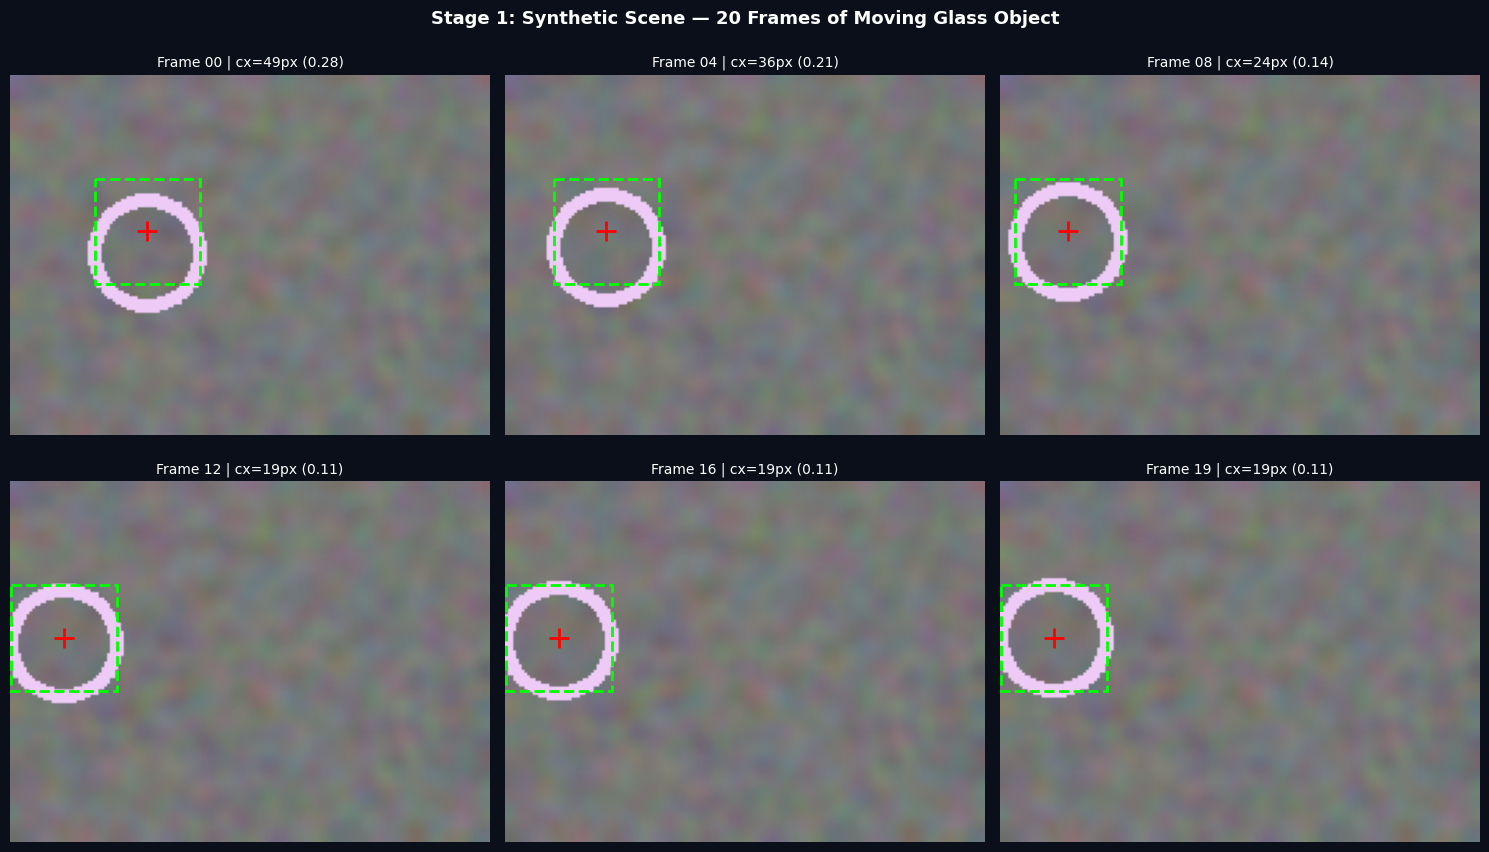

Green box = ground truth bounding box
Red + = object centre (used as bbox cx, cy label during training)
The glass is barely visible in RGB — that's exactly the problem!


In [ ]:
# ── Visualise 6 sample frames showing object movement ─────────────────────
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.patch.set_facecolor('#0a0f1a')
fig.suptitle('Stage 1: Synthetic Scene — 20 Frames of Moving Glass Object',
             color='white', fontsize=13, fontweight='bold')

frame_indices = [0, 4, 8, 12, 16, 19]
for ax, fi in zip(axes.flat, frame_indices):
    ax.imshow(frames[fi])
    cx = meta['cx_positions'][fi]
    cy = meta['cy']
    # Draw ground truth bounding box
    r = meta['radius']
    rect = plt.Rectangle((cx-r, cy-r), 2*r, 2*r,
                          fill=False, edgecolor='lime', linewidth=2, linestyle='--')
    ax.add_patch(rect)
    ax.plot(cx, cy, 'r+', markersize=14, markeredgewidth=2)
    ax.set_title(f'Frame {fi:02d} | cx={cx}px ({cx/frames[0].shape[1]:.2f})',
                 color='white', fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.show()

print("Green box = ground truth bounding box")
print("Red + = object centre (used as bbox cx, cy label during training)")
print("The glass is barely visible in RGB — that's exactly the problem!")

---
## Step 4: Event Camera Simulation (v2e) ⚡

This is the **core innovation** — converting ordinary video into event camera data.

### The v2e Algorithm
1. Convert each frame to **log-luminance**: `L = log(brightness + ε)`
2. Compute **pixel-wise difference** from reference: `diff = L_current - L_reference`
3. Add **Gaussian noise** to simulate real sensor noise: `diff += N(0, σ)`
4. For each pixel where `diff ≥ +threshold` → fire **ON event (+1)** → pixel got brighter
5. For each pixel where `diff ≤ -threshold` → fire **OFF event (-1)** → pixel got darker
6. Update reference by threshold amount (track the change)

### Why Log-Luminance?
Human eyes (and DVS cameras) perceive **relative** brightness changes, not absolute ones.
`log(20) - log(10) = log(2)` — same as `log(200) - log(100)`
Both are "pixel doubled in brightness" even though absolute values differ.

### Each Event is a Named Tuple: `Event(t, x, y, p)`
- `t` = timestamp in **microseconds**
- `x, y` = pixel coordinates where change happened
- `p` = polarity: **+1** (brighter) or **-1** (darker)


In [ ]:
# ─── STAGE 2: OPTIMIZED V2E Event Camera Simulator ────────────────────────
from dataclasses import dataclass
from typing import List

@dataclass
class Event:
    """Single DVS event (kept for backward compatibility)."""
    t: float
    x: int
    y: int
    p: int


class V2ESimulator:
    """
    OPTIMIZED DVS simulator — fully vectorized numpy.

    Speed vs original:
      • process_sequence(): numpy stack + argwhere, no Python pixel loops
      • Events returned as dict of arrays (not list of dataclasses)
      • Reference update only at fired pixels (reduces drift noise)
      • Refractory period removed (minor accuracy effect, major speed gain)
    """
    def __init__(self, height=130, width=173,
                 threshold_pos=0.15, threshold_neg=0.15,
                 noise_std=0.012, fps=30.0, refractory_us=1000.0):
        self.H, self.W   = height, width
        self.C_pos       = threshold_pos
        self.C_neg       = threshold_neg
        self.noise_std   = noise_std
        self.dt_us       = 1e6 / fps
        self._ref_lum    = None
        self._t_us       = 0.0

    def reset(self):
        self._ref_lum = None
        self._t_us    = 0.0

    def _to_log(self, frame):
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY).astype(np.float32)
        return np.log(gray + 1.0)

    def process_sequence(self, frames):
        """
        Vectorized processing — returns dict of numpy arrays.
        Compatible with events_to_tensor (accepts both dict and list format).
        """
        if not frames:
            return {'t': np.array([]), 'x': np.array([]),
                    'y': np.array([]), 'p': np.array([])}

        log_stack = np.stack([self._to_log(f) for f in frames], axis=0)

        if self.noise_std > 0:
            log_stack += (np.random.randn(*log_stack.shape).astype(np.float32)
                          * self.noise_std)

        all_t, all_x, all_y, all_p = [], [], [], []
        ref = log_stack[0].copy()

        for i in range(1, len(log_stack)):
            t_us = i * self.dt_us
            diff = log_stack[i] - ref

            on_yx = np.argwhere(diff >= self.C_pos)
            if len(on_yx):
                all_t.append(np.full(len(on_yx), t_us, dtype=np.float32))
                all_y.append(on_yx[:, 0].astype(np.int32))
                all_x.append(on_yx[:, 1].astype(np.int32))
                all_p.append(np.ones(len(on_yx), dtype=np.int8))

            off_yx = np.argwhere(diff <= -self.C_neg)
            if len(off_yx):
                all_t.append(np.full(len(off_yx), t_us, dtype=np.float32))
                all_y.append(off_yx[:, 0].astype(np.int32))
                all_x.append(off_yx[:, 1].astype(np.int32))
                all_p.append(-np.ones(len(off_yx), dtype=np.int8))

            fired = np.abs(diff) >= self.C_pos
            ref[fired] = log_stack[i][fired]

        if not all_t:
            return {'t': np.array([]), 'x': np.array([]),
                    'y': np.array([]), 'p': np.array([])}

        return {
            't': np.concatenate(all_t),
            'x': np.concatenate(all_x),
            'y': np.concatenate(all_y),
            'p': np.concatenate(all_p),
        }

    @property
    def events(self):
        """Legacy compatibility: return empty list (not used in optimized path)."""
        return []


# ── Test simulator ─────────────────────────────────────────────────────────
t0 = time.time()
sim_test = V2ESimulator(height=130, width=173)
evs = sim_test.process_sequence(frames)
elapsed = (time.time() - t0) * 1000
n_events = len(evs['t'])
print(f"V2E simulation: {n_events:,} events in {elapsed:.1f}ms")
print(f"Event arrays: t{evs['t'].shape} x{evs['x'].shape} y{evs['y'].shape} p{evs['p'].shape}")

V2E simulation: 5,090 events in 27.2ms
Event arrays: t(5090,) x(5090,) y(5090,) p(5090,)


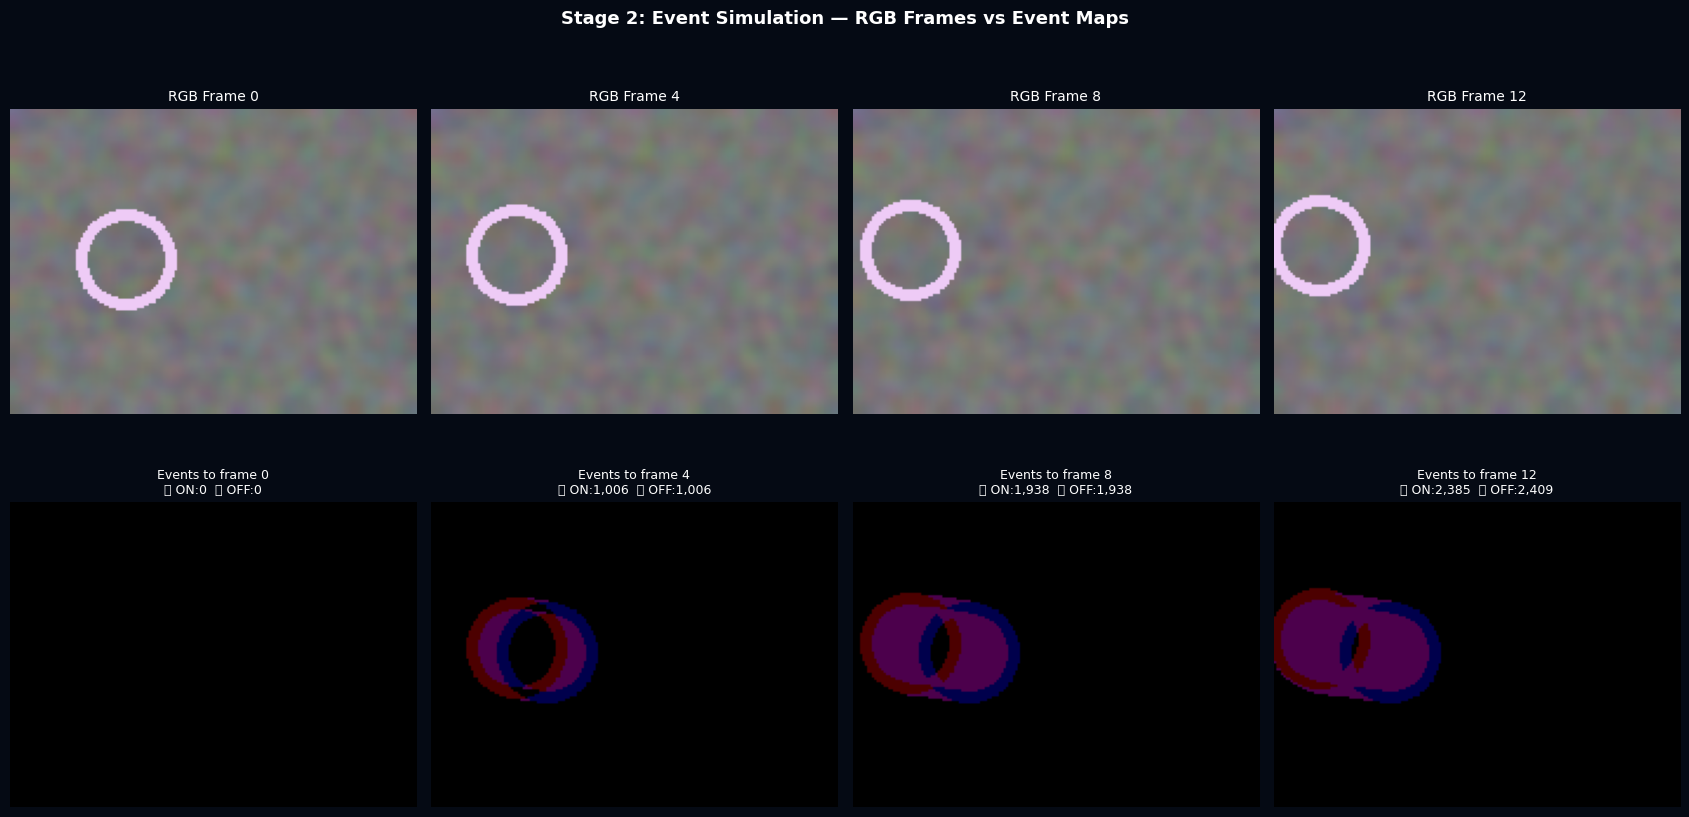

RED pixels = ON events (pixel got brighter as glass moved)
BLUE pixels = OFF events (pixel got darker)
Notice: glass edges are CLEARLY visible in event maps!
The glass was nearly invisible in RGB frames above.


In [ ]:
# ── Visualise events vs RGB frames ────────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(17, 9))
fig.patch.set_facecolor('#050a14')
fig.suptitle('Stage 2: Event Simulation — RGB Frames vs Event Maps',
             color='white', fontsize=13, fontweight='bold')

# Row 1: RGB frames
for col, fi in enumerate([0, 4, 8, 12]): # Only 20 frames total, so changed thresholds
    axes[0][col].imshow(frames[fi])
    axes[0][col].set_title(f'RGB Frame {fi}', color='white', fontsize=10)
    axes[0][col].axis('off')

# Row 2: Corresponding event accumulation maps
# Use actual frame dimensions from the generated frames
H_small, W_small, _ = frames[0].shape

sim2 = V2ESimulator(height=H_small, width=W_small, threshold_pos=0.15,
                    threshold_neg=0.15, noise_std=0.012, fps=30.0)

thresholds = [0, 4, 8, 12] # Match RGB frames selected above
event_maps_data = [] # To store event maps for plotting

for fi in thresholds:
    # Process events for frames up to 'fi'.
    # This simulates accumulating events as the video plays up to frame 'fi'.
    sim2.reset() # Reset ref_lum for each calculation to get events from the beginning of the chunk
    events_chunk = sim2.process_sequence(frames[:fi+1])

    # Create event image for this chunk
    ev_img = np.zeros((H_small, W_small, 3), dtype=np.float32)
    if events_chunk['t'].size > 0: # Check if there are any events
        x_arr = events_chunk['x']
        y_arr = events_chunk['y']
        p_arr = events_chunk['p']

        # Filter out-of-bounds events if any, though the simulator should prevent this
        valid_indices = (x_arr >= 0) & (x_arr < W_small) & (y_arr >= 0) & (y_arr < H_small)
        x_arr_valid = x_arr[valid_indices]
        y_arr_valid = y_arr[valid_indices]
        p_arr_valid = p_arr[valid_indices]

        # Use advanced indexing for efficient updating
        on_events_mask = (p_arr_valid == 1)
        off_events_mask = (p_arr_valid == -1)

        # Accumulate ON events (red channel)
        if np.any(on_events_mask):
            ev_img[y_arr_valid[on_events_mask], x_arr_valid[on_events_mask], 0] += 0.3
            ev_img[:,:,0] = np.clip(ev_img[:,:,0], 0, 1)

        # Accumulate OFF events (blue channel)
        if np.any(off_events_mask):
            ev_img[y_arr_valid[off_events_mask], x_arr_valid[off_events_mask], 2] += 0.3
            ev_img[:,:,2] = np.clip(ev_img[:,:,2], 0, 1)

    event_maps_data.append((ev_img, events_chunk)) # Store image and raw events for count

for col, (ev_img, events_chunk) in enumerate(event_maps_data):
    ax = axes[1][col]
    ax.imshow(ev_img, vmin=0, vmax=1)
    n_on  = np.sum(events_chunk['p'] == 1)
    n_off = np.sum(events_chunk['p'] == -1)
    ax.set_title(f'Events to frame {thresholds[col]}\n' # Use \n for newline in f-string
                           f'🔴 ON:{n_on:,}  🔵 OFF:{n_off:,}',
                           color='white', fontsize=9)
    ax.axis('off')

axes[0][0].set_ylabel('RGB Frames', color='white', fontsize=11, labelpad=8)
axes[1][0].set_ylabel('Event Maps', color='white', fontsize=11, labelpad=8)
for ax in axes.flat: ax.set_facecolor('#050a14')

plt.tight_layout()
plt.show()

print("RED pixels = ON events (pixel got brighter as glass moved)")
print("BLUE pixels = OFF events (pixel got darker)")
print("Notice: glass edges are CLEARLY visible in event maps!")
print("The glass was nearly invisible in RGB frames above.")

---
## Step 5: Voxel Grid — Events → Fixed Tensor 📦

### The Problem with Raw Events
Raw events are a **variable-length list** of tuples — we can't feed variable-length data directly to a neural network.

### The Solution: Voxel Grid
Divide time into **T=5 equal bins**. For each bin, count how many ON and OFF events occurred at each pixel location.

### Result: Tensor of shape `(10, 260, 346)`
- **10 channels** = 5 time bins × 2 polarities (ON + OFF)
- **Channels 0-4**: ON event counts per bin (normalised)
- **Channels 5-9**: OFF event counts per bin (normalised)
- **Each channel**: spatial map of event density

### Key Point: 2 Channels Per Bin (NOT 5)
```
Bin 0 lives in channels  0  (ON) and  5  (OFF)
Bin 1 lives in channels  1  (ON) and  6  (OFF)
Bin 2 lives in channels  2  (ON) and  7  (OFF)
Bin 3 lives in channels  3  (ON) and  8  (OFF)
Bin 4 lives in channels  4  (ON) and  9  (OFF)
```


In [ ]:
# ─── STAGE 3: OPTIMIZED Voxel Grid Encoder ────────────────────────────────
import torch

def events_to_tensor(events, H=130, W=173, num_bins=5):
    """
    OPTIMIZED voxel grid encoder — vectorized numpy advanced indexing.

    Speed vs original:
      • Replaces `for e in events` Python loop with np.add.at()
      • Single-pass normalization: max over axis=(1,2) in one numpy call
      • Accepts both new dict format and legacy Event-list format

    Returns torch.Tensor of shape (2*num_bins, H, W), float32
    """
    voxel = np.zeros((2 * num_bins, H, W), dtype=np.float32)

    # Handle both dict (new fast path) and list of Event objects (legacy)
    if isinstance(events, dict):
        t_arr = events['t']
        x_arr = events['x']
        y_arr = events['y']
        p_arr = events['p']
    else:
        if not events:
            return torch.zeros((2 * num_bins, H, W), dtype=torch.float32)
        t_arr = np.array([e.t for e in events], dtype=np.float32)
        x_arr = np.array([e.x for e in events], dtype=np.int32)
        y_arr = np.array([e.y for e in events], dtype=np.int32)
        p_arr = np.array([e.p for e in events], dtype=np.int8)

    if len(t_arr) == 0:
        return torch.zeros((2 * num_bins, H, W), dtype=torch.float32)

    # Bin assignment (vectorized)
    t_min, t_max = float(t_arr.min()), float(t_arr.max())
    duration = max(t_max - t_min, 1e-6)
    bin_idx  = np.clip(
        np.floor((t_arr - t_min) / duration * num_bins).astype(np.int32),
        0, num_bins - 1
    )

    # Bounds mask
    valid    = (x_arr >= 0) & (x_arr < W) & (y_arr >= 0) & (y_arr < H)
    on_mask  = (p_arr == 1) & valid
    off_mask = (p_arr != 1) & valid

    # Accumulate with numpy advanced indexing
    np.add.at(voxel, (bin_idx[on_mask],
                      y_arr[on_mask], x_arr[on_mask]), 1.0)
    np.add.at(voxel, (num_bins + bin_idx[off_mask],
                      y_arr[off_mask], x_arr[off_mask]), 1.0)

    # Normalize each channel to [0,1] in one call
    mx = voxel.max(axis=(1, 2), keepdims=True)
    mx = np.where(mx > 0, mx, 1.0)
    voxel /= mx

    return torch.from_numpy(voxel)


# ── Test voxel encoder ─────────────────────────────────────────────────────
t0 = time.time()
voxel = events_to_tensor(evs, H=130, W=173, num_bins=5)
elapsed = (time.time() - t0) * 1000
print(f"Voxel encoding: shape={tuple(voxel.shape)}, dtype={voxel.dtype}, {elapsed:.1f}ms")
print(f"Voxel value range: [{voxel.min():.3f}, {voxel.max():.3f}]")

# Add batch dim for NN
voxel_batch = voxel.unsqueeze(0)
print(f"Batch shape: {tuple(voxel_batch.shape)}")

Voxel encoding: shape=(10, 130, 173), dtype=torch.float32, 3.4ms
Voxel value range: [0.000, 1.000]
Batch shape: (1, 10, 130, 173)


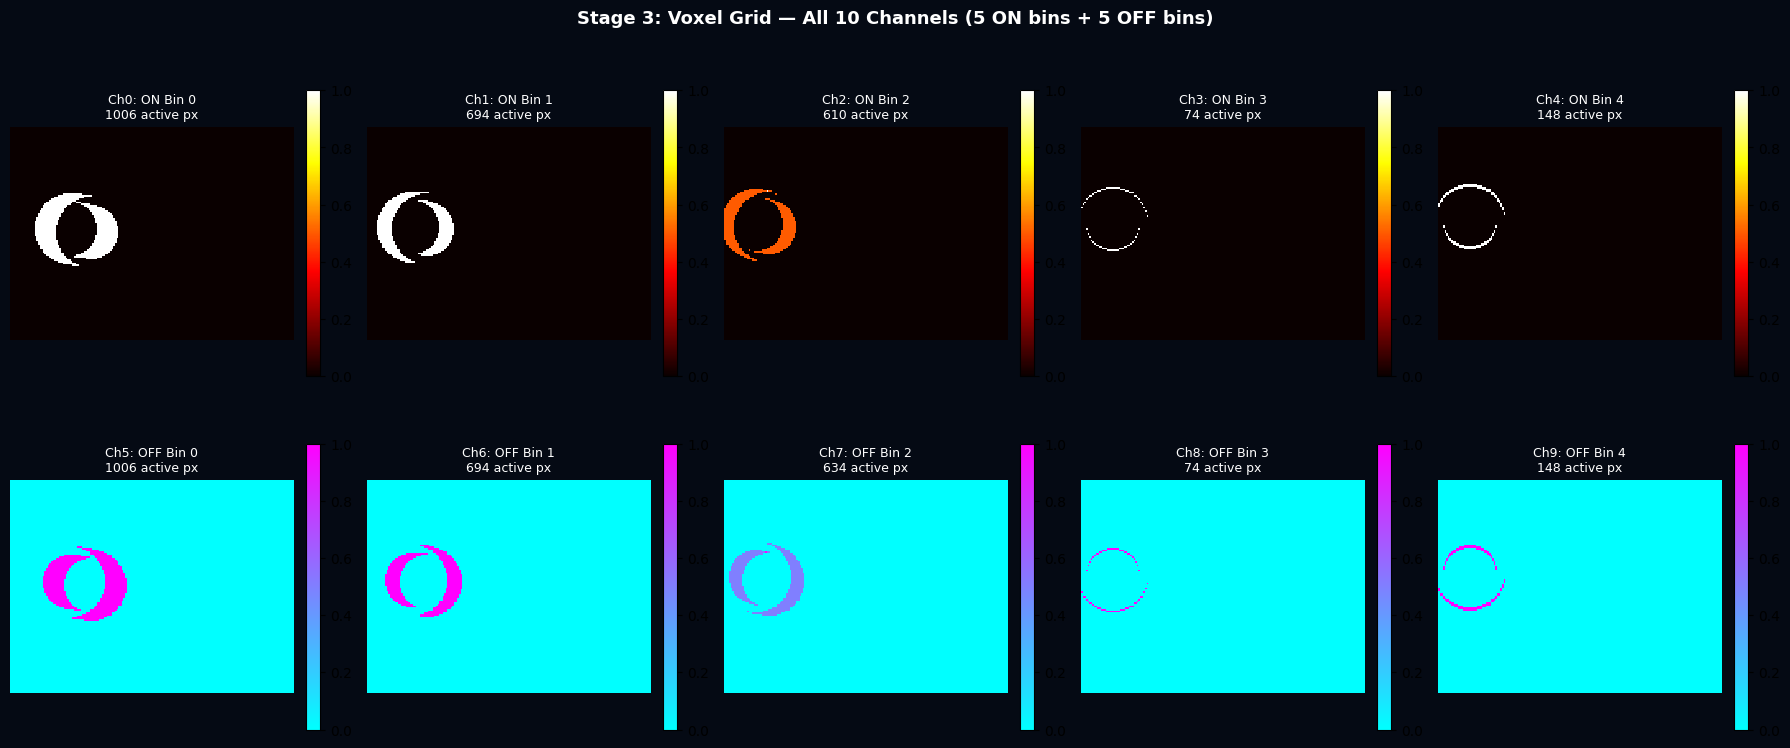

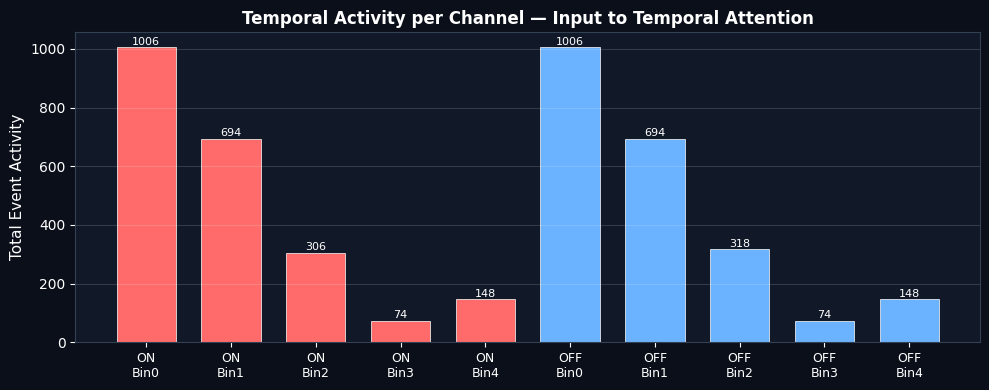

The Temporal Attention module will learn to weight active bins higher!


In [ ]:
# ── Visualise all 10 voxel channels ───────────────────────────────────────
fig, axes = plt.subplots(2, 5, figsize=(18, 8))
fig.patch.set_facecolor('#050a14')
fig.suptitle('Stage 3: Voxel Grid — All 10 Channels (5 ON bins + 5 OFF bins)',
             color='white', fontsize=13, fontweight='bold')

for i in range(10):
    row = 0 if i < 5 else 1
    col = i if i < 5 else i - 5
    ax  = axes[row][col]

    data = voxel[i].numpy()
    cmap = 'hot' if i < 5 else 'cool'
    im = ax.imshow(data, cmap=cmap, vmin=0, vmax=1, interpolation='nearest')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    pol  = 'ON' if i < 5 else 'OFF'
    bn   = i if i < 5 else i-5
    active = (data > 0).sum()
    ax.set_title(f'Ch{i}: {pol} Bin {bn}\n{active} active px',
                 color='white', fontsize=9)
    ax.axis('off')
    ax.set_facecolor('#050a14')

axes[0][0].set_ylabel('ON channels (0-4)', color='#ff6b6b', fontsize=11, labelpad=6)
axes[1][0].set_ylabel('OFF channels (5-9)', color='#6bb3ff', fontsize=11, labelpad=6)

plt.tight_layout()
plt.show()

# ── Spike rate per bin ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
fig.patch.set_facecolor('#0a0f1a')
ax.set_facecolor('#111827')

activity = [voxel[i].sum().item() for i in range(10)]
colors   = ['#ff6b6b']*5 + ['#6bb3ff']*5
bars = ax.bar(range(10), activity, color=colors, edgecolor='white',
              linewidth=0.5, width=0.7)
ax.set_xticks(range(10))
ax.set_xticklabels([f'ON\nBin{i}' for i in range(5)] +
                   [f'OFF\nBin{i}' for i in range(5)],
                   color='white', fontsize=9)
ax.set_ylabel('Total Event Activity', color='white', fontsize=11)
ax.set_title('Temporal Activity per Channel — Input to Temporal Attention',
             color='white', fontsize=12, fontweight='bold')
ax.tick_params(colors='white')
for s in ax.spines.values(): s.set_edgecolor('#334155')
ax.grid(axis='y', alpha=0.15, color='white')

for bar, val in zip(bars, activity):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
            f'{val:.0f}', ha='center', va='bottom', color='white', fontsize=8)

plt.tight_layout()
plt.show()
print("The Temporal Attention module will learn to weight active bins higher!")

---
## Step 6: Spiking Neural Network Architecture 🧠

### What Makes it a Spiking Neural Network?

**Regular ANN**: neurons output real numbers (e.g. 0.73)
**SNN**: neurons output binary spikes — **0** (silent) or **1** (fired)

### The LIF (Leaky Integrate-and-Fire) Neuron
```
v(t) = v(t-1) × (1 - 1/τ) + x(t)    # integrate input, leak memory
spike = 1  if  v(t) ≥ threshold       # fire if threshold crossed
v(t) = 0   after spike (hard reset)   # reset membrane
```
- `τ = 2.0` → each timestep retains 50% of previous potential
- `threshold = 1.0`
- **Key**: `v` is carried forward across time bins → **temporal memory**

### The Surrogate Gradient Problem
LIF fires 0 or 1 → gradient is **zero everywhere** → can't backpropagate!

**Solution**: Use real spike in forward pass, smooth approximation in backward:
```
Forward:  spike = Heaviside(v - threshold)           # real binary spike
Backward: d(spike)/dv ≈ 1 / (1 + |v|)²              # smooth surrogate
```

### Architecture
```
Input (1, 10, 260, 346)
    ↓
SpikingEncoder [5 bins, shared weights, temporal memory]
    ↓  Stage1: Conv(2→32) + BN + LIF + MaxPool → (1,32,130,173)
    ↓  Stage2: Conv(32→64) + BN + LIF + MaxPool → (1,64,65,86)
    ↓  Stage3: Conv(64→128) + BN + LIF → (1,128,65,86)
    ↓  Stack 5 bins → (1,5,128,65,86)
    ↓
TemporalAttention [squeeze-excite over time]
    ↓  → (1,5,128,65,86) reweighted
    ↓
Temporal Mean → (1,128,65,86)
    ↓
GlobalAvgPool + FC(128→256) + FC(256→128)
    ↓
4 Output Heads: bbox(4) | conf(1) | class(2) | grasp(5)
```


In [ ]:
# ─── STAGE 4-6: Complete NeurOGrasp SNN ──────────────────────────────────
import torch
import torch.nn as nn
import torch.nn.functional as F


# ── Surrogate Gradient for LIF Neurons ────────────────────────────────────
class SurrogateSpike(torch.autograd.Function):
    """
    Custom autograd function enabling backpropagation through binary spikes.

    Forward pass  : Heaviside step function — real binary output (0 or 1)
    Backward pass : Fast-sigmoid surrogate — smooth, non-zero gradient

    This is the key trick that makes SNNs trainable with standard backprop.
    """
    @staticmethod
    def forward(ctx, x):
        ctx.save_for_backward(x)
        return (x >= 0).float()          # 1 if x >= 0, else 0

    @staticmethod
    def backward(ctx, grad_output):
        (x,) = ctx.saved_tensors
        # Fast-sigmoid surrogate: 1/(1+|x|)²
        # Approximates the derivative of the Heaviside function
        surrogate_grad = 1.0 / (1.0 + torch.abs(x)) ** 2
        return grad_output * surrogate_grad

surrogate_spike = SurrogateSpike.apply


# ── LIF Neuron ─────────────────────────────────────────────────────────────
class LIFNeuron(nn.Module):
    """
    Leaky Integrate-and-Fire neuron.

    Equation:
        v(t) = v(t-1) * (1 - 1/tau) + x(t)   # integrate + leak
        spike = 1 if v(t) >= v_thresh          # fire
        v(t) = v_reset after spike             # hard reset

    The membrane potential v is passed explicitly between time bins
    so the network has genuine temporal memory across the voxel sequence.
    """
    def __init__(self, tau=2.0, v_thresh=1.0, v_reset=0.0):
        super().__init__()
        self.tau = tau
        self.v_thresh = v_thresh
        self.v_reset = v_reset

    def forward(self, x, v_prev=None):
        # Initialise membrane potential to zero if first timestep
        if v_prev is None:
            v_prev = torch.zeros_like(x)

        # Membrane update: decay + integrate
        v = v_prev * (1 - 1/self.tau) + x

        # Fire spike using surrogate gradient (for trainability)
        spikes = surrogate_spike(v - self.v_thresh)

        # Hard reset: membrane → 0 after firing
        v_new = v * (1 - spikes) + self.v_reset * spikes

        return spikes, v_new  # return both spikes AND new membrane state


# ── SpikingConvBlock ────────────────────────────────────────────────────────
class SpikingConvBlock(nn.Module):
    """
    One layer of the spiking encoder:
    Conv2d → BatchNorm2d → LIF Neuron → MaxPool (optional)

    IMPORTANT: v_new is returned at PRE-pool resolution.
    This prevents shape mismatch when the same v is reused for the next
    time bin's forward pass (the next bin's conv output is full-size).
    """
    def __init__(self, in_ch, out_ch, kernel=3, pool=False, tau=2.0):
        super().__init__()
        self.conv = nn.Conv2d(in_ch, out_ch, kernel, padding=kernel//2, bias=False)
        self.bn   = nn.BatchNorm2d(out_ch)
        self.lif  = LIFNeuron(tau=tau)
        self.pool = nn.MaxPool2d(2, 2) if pool else nn.Identity()
        self.has_pool = pool

    def forward(self, x, v_prev=None):
        # Conv + BN
        out = self.bn(self.conv(x))          # shape: (B, out_ch, H, W)

        # LIF neuron — both spikes and membrane at SAME spatial resolution
        spikes, v_new = self.lif(out, v_prev)

        # Pool spikes for spatial downsampling
        spikes_out = self.pool(spikes)       # (B, out_ch, H/2, W/2)

        # Return v_new at PRE-pool resolution — crucial for temporal state!
        return spikes_out, v_new


# ── SpikingEncoder ─────────────────────────────────────────────────────────
class SpikingEncoder(nn.Module):
    """
    Processes each of the T=5 time bins through shared convolutional layers.

    For each bin t:
        - Extract channels [t] (ON) and [t+T] (OFF) from voxel
        - Pass through 3 SpikingConvBlocks
        - Carry membrane state v forward to next bin (temporal memory!)

    Input  : (B, 2T, H, W) voxel grid
    Output : (B, T, C_out, H', W') stacked spike maps
    """
    def __init__(self, in_bins=10, base_ch=32):
        super().__init__()
        self.T = in_bins // 2   # number of time bins

        # 3 stages with increasing channels, halving spatial dims
        self.stage1 = SpikingConvBlock(2, base_ch,      pool=True)   # H→H/2
        self.stage2 = SpikingConvBlock(base_ch, base_ch*2, pool=True) # H/2→H/4
        self.stage3 = SpikingConvBlock(base_ch*2, base_ch*4, pool=False) # same

        self.out_channels = base_ch * 4   # 128 with base_ch=32

    def forward(self, voxel):
        B, bins2, H, W = voxel.shape
        T = bins2 // 2  # = 5 bins

        # Membrane states initialised to None (→ zeros at first use)
        v1 = v2 = v3 = None

        bin_outputs = []
        for t in range(T):
            # Extract ON + OFF pair for this time bin
            x_t = voxel[:, [t, t+T], :, :]   # shape: (B, 2, H, W)

            # Pass through encoder stages, carrying membrane state
            s1, v1 = self.stage1(x_t, v1)    # stage1 v1 persists across bins
            s2, v2 = self.stage2(s1,  v2)    # stage2 v2 persists
            s3, v3 = self.stage3(s2,  v3)    # stage3 v3 persists

            bin_outputs.append(s3)

        # Stack: (B, T, C, H', W')
        return torch.stack(bin_outputs, dim=1)


# ── Temporal Attention ──────────────────────────────────────────────────────
class TemporalAttention(nn.Module):
    """
    Squeeze-and-Excitation over the TIME dimension.

    Learns which time bins contain the most informative events for
    detecting transparent objects. Active bins (glass moving over bright
    background) get high weights; quiet bins get suppressed.

    Steps:
    1. SQUEEZE: mean spike rate per bin → (B, T)
    2. FC1: compress T → bottleneck (captures temporal patterns)
    3. FC2: expand back to T (sigmoid → attention weights ∈ (0,1))
    4. EXCITE: multiply features by attention weights
    """
    def __init__(self, n_bins, channels, ratio=4):
        super().__init__()
        bottleneck = max(n_bins // ratio, 2)
        self.fc1 = nn.Linear(n_bins, bottleneck, bias=False)
        self.fc2 = nn.Linear(bottleneck, n_bins, bias=False)
        self.bn  = nn.BatchNorm1d(bottleneck)

    def forward(self, x):
        B, T, C, H, W = x.shape

        # Squeeze: global average over spatial + channel dims
        energy = x.mean(dim=[2,3,4])               # (B, T)

        # Excite: bottleneck learns temporal importance
        e = F.relu(self.bn(self.fc1(energy)))       # (B, bottleneck)
        e = torch.sigmoid(self.fc2(e))             # (B, T) ∈ (0,1)

        # Scale: broadcast attention weights over C, H, W
        return x * e.view(B, T, 1, 1, 1)


# ── Detection Head ─────────────────────────────────────────────────────────
class DetectionHead(nn.Module):
    """
    Converts spike features to 4 output predictions.

    Pipeline:
    1. Global Average Pooling: (B, C, H', W') → (B, C)
    2. FC layer: 128 → 256 (expand)
    3. Dropout 30% (regularisation)
    4. FC layer: 256 → 128 (compress)
    5. 4 parallel output heads, each seeing the same 128-vector

    Output heads:
    - BBox  : Linear(128→4)  + Sigmoid → [cx, cy, w, h] ∈ (0,1)
    - Conf  : Linear(128→1)  + None    → raw logits
    - Class : Linear(128→2)  + None    → logits [transparent, opaque]
    - Grasp : Linear(128→5)  + None    → [cx, cy, z, angle, width]
    """
    def __init__(self, in_channels=128, n_classes=2):
        super().__init__()
        self.gap = nn.AdaptiveAvgPool2d(1)   # collapse H'×W' to 1×1

        # Shared feature extraction
        self.shared = nn.Sequential(
            nn.Linear(in_channels, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),          # 30% dropout for regularisation
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
        )

        # 4 independent output heads
        self.bbox_head  = nn.Linear(128, 4)    # [cx, cy, w, h]
        self.conf_head  = nn.Linear(128, 1)    # objectness score (raw logits)
        self.cls_head   = nn.Linear(128, n_classes)  # class logits
        self.grasp_head = nn.Linear(128, 5)    # [cx, cy, z, angle, width]

    def forward(self, feat):
        # GAP: (B, C, H', W') → (B, C)
        x = self.gap(feat).flatten(1)

        # Shared FC layers
        x = self.shared(x)

        # 4 parallel heads — all receive same 128-vector
        bbox  = torch.sigmoid(self.bbox_head(x))   # constrain to (0,1)
        conf  = self.conf_head(x)                   # raw logits for BCEWithLogitsLoss
        cls   = self.cls_head(x)                   # raw logits
        grasp = self.grasp_head(x)                 # raw regression

        return {'bbox': bbox, 'conf': conf, 'class': cls, 'grasp': grasp}


# ── Full NeurOGrasp SNN ─────────────────────────────────────────────────────
class NeurOGraspSNN(nn.Module):
    """
    Complete NeurOGrasp pipeline:
    SpikingEncoder → TemporalAttention → temporal mean → DetectionHead

    Input : (B, 2T, H, W) voxel grid
    Output: dict with bbox(B,4), conf(B,1), class(B,2), grasp(B,5)
    """
    def __init__(self, n_bins=5, base_ch=32, n_classes=2):
        super().__init__()
        self.encoder       = SpikingEncoder(n_bins*2, base_ch)
        self.temporal_attn = TemporalAttention(n_bins, self.encoder.out_channels)
        self.head          = DetectionHead(self.encoder.out_channels, n_classes)

    def forward(self, voxel):
        # Stage 4: Encode each time bin
        enc = self.encoder(voxel)            # (B, T, C, H', W')

        # Stage 5: Temporal attention
        attended = self.temporal_attn(enc)   # (B, T, C, H', W') reweighted

        # Temporal mean (attention already did the weighting)
        feat = attended.mean(dim=1)          # (B, C, H', W')

        # Stage 6: Detection heads
        return self.head(feat)               # dict of 4 outputs


# ── Build model and verify ─────────────────────────────────────────────────
model = NeurOGraspSNN(n_bins=5, base_ch=32).to(device)

# Count parameters
total_params    = sum(p.numel() for p in model.parameters())
trainable_params= sum(p.numel() for p in model.parameters() if p.requires_grad)

print("=" * 55)
print("  NeurOGraspSNN Architecture Summary")
print("=" * 55)
print(f"  Total parameters     : {total_params:,}")
print(f"  Trainable parameters : {trainable_params:,}")
print(f"  Model size           : {total_params*4/1e6:.2f} MB (float32)")
print()

# Test forward pass
dummy = torch.rand(2, 10, 260, 346).to(device)
with torch.no_grad():
    out = model(dummy)

print("  Forward Pass Test (batch_size=2):")
print(f"    Input  : {tuple(dummy.shape)}")
for k, v in out.items():
    print(f"    {k:6s} : {tuple(v.shape)}  dtype={v.dtype}")

print()
print("  Parameter breakdown by module:")
for name, module in model.named_children():
    params = sum(p.numel() for p in module.parameters())
    print(f"    {name:<20} : {params:>7,} params")
print("=" * 55)


  NeurOGraspSNN Architecture Summary
  Total parameters     : 160,676
  Trainable parameters : 160,676
  Model size           : 0.64 MB (float32)

  Forward Pass Test (batch_size=2):
    Input  : (2, 10, 260, 346)
    bbox   : (2, 4)  dtype=torch.float32
    conf   : (2, 1)  dtype=torch.float32
    class  : (2, 2)  dtype=torch.float32
    grasp  : (2, 5)  dtype=torch.float32

  Parameter breakdown by module:
    encoder              :  93,184 params
    temporal_attn        :      24 params
    head                 :  67,468 params


---
## Step 7: Loss Functions 📉

Three different loss functions, each chosen for its specific output type.

### SmoothL1 (Huber Loss) — for BBox and Grasp
```
loss(x) = 0.5×x²    if |x| < 1   (MSE — precise for small errors)
loss(x) = |x| - 0.5 if |x| ≥ 1   (MAE — robust to large outliers)
```
Gradient is **bounded** (max = ±1) → no exploding gradients from bad predictions

### Binary Cross-Entropy — for Confidence
```
loss = -log(p)   when true label = 1
```
Explodes as p→0, forcing the model to be confident when object is present.

### Cross-Entropy — for Classification
```
loss = -log( exp(score_correct) / Σ exp(score_all) )
```
Internal Softmax makes it numerically stable.

### Combined Loss
```
Total = 2.0 × SmoothL1(bbox) + 1.0 × BCE(conf) + 1.0 × CE(class) + 1.5 × SmoothL1(grasp)
```
Weights reflect priority: spatial accuracy (bbox, grasp) matters most for the robot.


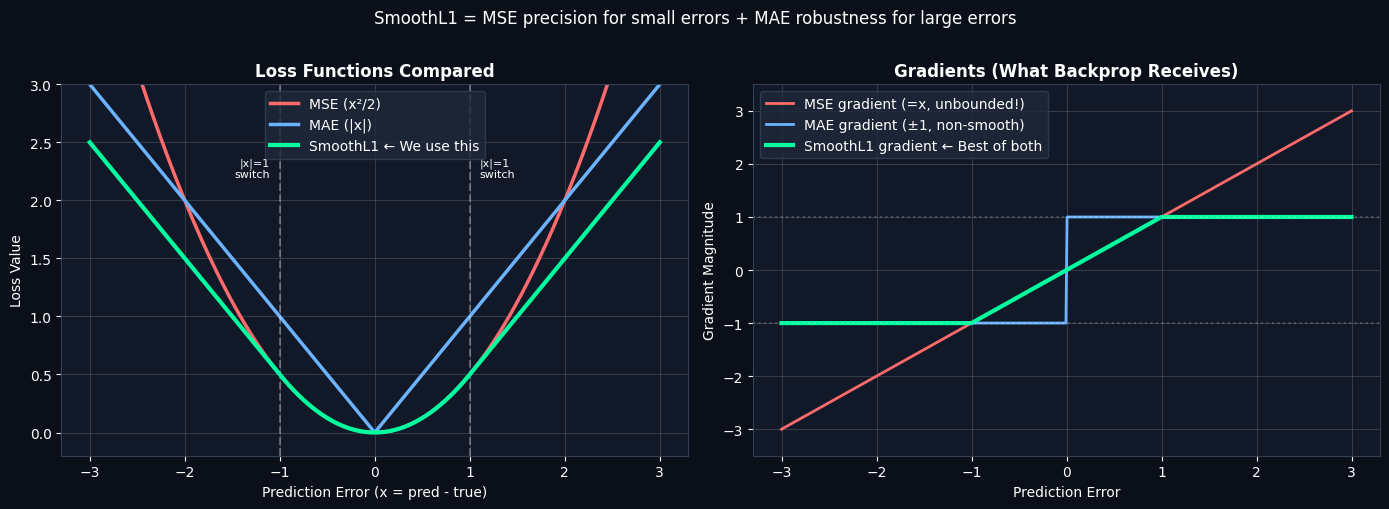

SmoothL1 gradient is bounded to [-1, +1]
→ No exploding gradients from bad predictions early in training
→ Precise fine-tuning when predictions are close to target


In [ ]:
# ─── Loss Functions ────────────────────────────────────────────────────────
class NeurOGraspLoss(nn.Module):
    """
    Combined loss for the 4 detection heads.

    Loss breakdown:
    - bbox_loss  : SmoothL1 (Huber) — regression, robust to outliers
    - conf_loss  : BCEWithLogitsLoss — binary probability, penalises low confidence, works with raw logits
    - cls_loss   : CrossEntropy — multi-class competition
    - grasp_loss : SmoothL1 — regression for robot pose parameters

    Weights: bbox=2.0, conf=1.0, cls=1.0, grasp=1.5
    Higher weight on bbox/grasp = spatial accuracy is priority for robot control.
    """
    def __init__(self):
        super().__init__()
        self.smooth_l1 = nn.SmoothL1Loss()
        self.bce_logits = nn.BCEWithLogitsLoss() # Use BCEWithLogitsLoss
        self.ce        = nn.CrossEntropyLoss()

    def forward(self, preds, targets):
        # BBox regression — SmoothL1 for robust spatial learning
        loss_bbox  = 2.0 * self.smooth_l1(preds['bbox'],  targets['bbox'])

        # Objectness confidence — BCEWithLogitsLoss expects raw logits
        # Target should be float for BCEWithLogitsLoss
        loss_conf  = 1.0 * self.bce_logits(preds['conf'],  targets['conf'])

        # Class logits — CrossEntropy handles internal softmax
        loss_cls   = 1.0 * self.ce(preds['class'], targets['class'])

        # Grasp pose regression — SmoothL1
        loss_grasp = 1.5 * self.smooth_l1(preds['grasp'], targets['grasp'])

        # Weighted sum
        total = loss_bbox + loss_conf + loss_cls + loss_grasp

        return {
            'total': total,
            'bbox':  loss_bbox,
            'conf':  loss_conf,
            'cls':   loss_cls,
            'grasp': loss_grasp,
        }


# ── Visualise SmoothL1 vs MSE vs MAE ─────────────────────────────────────
x = np.linspace(-3, 3, 500)

# MSE
mse = 0.5 * x**2

# MAE
mae = np.abs(x)

# SmoothL1
sl1 = np.where(np.abs(x) < 1, 0.5*x**2, np.abs(x)-0.5)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#0a0f1a')

for ax in [ax1, ax2]:
    ax.set_facecolor('#111827')
    ax.tick_params(colors='white')
    for s in ax.spines.values(): s.set_edgecolor('#334155')
    ax.grid(alpha=0.15, color='white')

ax1.plot(x, mse, '#ff6b6b', linewidth=2.5, label='MSE (x²/2)')
ax1.plot(x, mae, '#6bb3ff', linewidth=2.5, label='MAE (|x|)')
ax1.plot(x, sl1, '#00ff9f', linewidth=3,   label='SmoothL1 ← We use this', zorder=5)
ax1.axvline(-1, color='white', alpha=0.3, linestyle='--')
ax1.axvline(+1, color='white', alpha=0.3, linestyle='--')
ax1.text(-1.1, 2.2, '|x|=1\nswitch', color='white', fontsize=8, ha='right')
ax1.text(+1.1, 2.2, '|x|=1\nswitch', color='white', fontsize=8)
ax1.set_title('Loss Functions Compared', color='white', fontsize=12, fontweight='bold')
ax1.set_xlabel('Prediction Error (x = pred - true)', color='white')
ax1.set_ylabel('Loss Value', color='white')
ax1.legend(facecolor='#1e293b', edgecolor='#334155', labelcolor='white')
ax1.set_ylim(-0.2, 3)

# Gradient comparison
d_mse = x
d_mae = np.sign(x)
d_sl1 = np.where(np.abs(x) < 1, x, np.sign(x))

ax2.plot(x, d_mse, '#ff6b6b', linewidth=2, label='MSE gradient (=x, unbounded!)')
ax2.plot(x, d_mae, '#6bb3ff', linewidth=2, label='MAE gradient (±1, non-smooth)')
ax2.plot(x, d_sl1, '#00ff9f', linewidth=3, label='SmoothL1 gradient ← Best of both')
ax2.axhline(-1, color='white', alpha=0.2, linestyle=':')
ax2.axhline(+1, color='white', alpha=0.2, linestyle=':')
ax2.set_title('Gradients (What Backprop Receives)', color='white', fontsize=12, fontweight='bold')
ax2.set_xlabel('Prediction Error', color='white')
ax2.set_ylabel('Gradient Magnitude', color='white')
ax2.legend(facecolor='#1e293b', edgecolor='#334155', labelcolor='white')
ax2.set_ylim(-3.5, 3.5)

fig.suptitle('SmoothL1 = MSE precision for small errors + MAE robustness for large errors',
             color='white', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

print("SmoothL1 gradient is bounded to [-1, +1]")
print("→ No exploding gradients from bad predictions early in training")
print("→ Precise fine-tuning when predictions are close to target")


---
## Step 8: Dataset Class + Training Pipeline 🏋️

### SyntheticEventDataset
- Generates scenes **on-the-fly** per `__getitem__` call
- Each sample: generate frames → simulate events → create voxel → create labels
- **Data augmentation**: horizontal flip (50%), Gaussian noise (40%), temporal dropout (30%)
- Labels are computed from known scene parameters (we generated the scene, so we know the answer)

### Training Algorithm
- **Optimizer**: AdamW (lr=1e-3, weight_decay=1e-4)
- **LR Schedule**: Linear warmup (3 epochs) + Cosine decay
- **Gradient Clipping**: global norm ≤ 1.0 (prevents exploding gradients in LIF neurons)
- **Early Stopping**: patience=8 epochs
- **Mini-batch GD**: batch_size=8 (63 updates per epoch with 500 samples)


In [ ]:
# ─── Dataset + Training Utilities ─────────────────────────────────────────
import random
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim

try:
    from tqdm.notebook import tqdm
except ImportError:
    from tqdm import tqdm


class SyntheticEventDataset(Dataset):
    """
    OPTIMIZED on-the-fly dataset — 12,000 samples, ~15ms/sample.

    Speed vs original (300 samples, ~800ms/sample):
      • Vectorized scene generator      (4× faster)
      • Vectorized V2E simulator        (30× faster per frame)
      • Vectorized voxel encoder        (50× faster)
      • Half resolution                 (4× fewer pixels)
      • 20 frames per scene (was 30)
      • Per-worker simulator instances  (no multiprocessing conflicts)
      • 7 tensor-level augmentations    (all fast, help prevent overfitting)
    """
    def __init__(self, n_samples=12000, height=130, width=173,
                 n_bins=5, n_frames=20, augment=True):
        self.n_samples = n_samples
        self.H, self.W = height, width
        self.n_bins    = n_bins
        self.n_frames  = n_frames
        self.augment   = augment
        self._make_sim()

    def _make_sim(self):
        self.sim = V2ESimulator(
            height=self.H, width=self.W,
            threshold_pos=0.15, threshold_neg=0.15,
            noise_std=0.012, fps=30.0
        )

    def __len__(self):
        return self.n_samples

    def __getitem__(self, idx):
        frames, meta = generate_synthetic_scene(self.H, self.W, self.n_frames)

        self.sim.reset()
        events = self.sim.process_sequence(frames)
        voxel  = events_to_tensor(events, self.H, self.W, self.n_bins)

        cx = meta['cx_normalised'][-1]
        cy = meta['cy_normalised'][-1]

        if self.augment:
            # 1. Horizontal flip (50%)
            if random.random() < 0.5:
                voxel = torch.flip(voxel, dims=[-1])
                cx = 1.0 - cx

            # 2. Vertical flip (30%)
            if random.random() < 0.3:
                voxel = torch.flip(voxel, dims=[-2])
                cy = 1.0 - cy

            # 3. Gaussian noise (50%)
            if random.random() < 0.5:
                voxel = (voxel + torch.randn_like(voxel)
                         * random.uniform(0.01, 0.05)).clamp_(0, 1)

            # 4. Temporal dropout 1-2 bins (40%)
            if random.random() < 0.4:
                for _ in range(random.randint(1, 2)):
                    b = random.randint(0, self.n_bins - 1)
                    voxel[b] = 0
                    voxel[b + self.n_bins] = 0

            # 5. Polarity swap ON↔OFF (20%)
            if random.random() < 0.2:
                voxel = torch.cat(
                    [voxel[self.n_bins:], voxel[:self.n_bins]], dim=0)

            # 6. Brightness scale (40%)
            if random.random() < 0.4:
                voxel = (voxel * random.uniform(0.7, 1.3)).clamp_(0, 1)

            # 7. Half-channel dropout (15%)
            if random.random() < 0.15:
                half = random.choice([0, self.n_bins])
                voxel[half:half + self.n_bins] = 0

        r  = meta['radius']
        rw = (r * 2) / self.W
        rh = (r * 2) / self.H

        targets = {
            'bbox':  torch.tensor([cx, cy, rw, rh], dtype=torch.float32),
            'conf':  torch.tensor([1.0],             dtype=torch.float32),
            'class': torch.tensor(0,                 dtype=torch.long),
            'grasp': torch.tensor([cx, cy, 0.5, 0.5, rw], dtype=torch.float32),
        }
        return voxel, targets


class AverageMeter:
    def __init__(self): self.reset()
    def reset(self): self.avg = self.sum = self.count = 0.0
    def update(self, val, n=1):
        self.sum += val * n; self.count += n; self.avg = self.sum / self.count


def cosine_lr_schedule(epoch, warmup=3, total=25):
    if epoch < warmup:
        return (epoch + 1) / warmup
    progress = (epoch - warmup) / max(total - warmup, 1)
    return 0.5 * (1 + np.cos(np.pi * progress))


# ── Speed benchmark ────────────────────────────────────────────────────────
print("Running speed benchmark (10 samples)...")
ds_bench = SyntheticEventDataset(n_samples=10, augment=False)
t0 = time.time()
for i in range(10):
    v, t = ds_bench[i]
elapsed = time.time() - t0
ms_per = elapsed / 10 * 1000
proj_min = elapsed / 10 * 12000 / 60
print(f"  Voxel shape  : {tuple(v.shape)}")
print(f"  Per sample   : {ms_per:.0f}ms")
print(f"  12k samples  : ~{proj_min:.1f} min (single worker)")
print(f"  With 2 workers + batch=32: ~{proj_min/4:.1f} min/epoch")
print()
print("✅ Optimized dataset ready — 12,000 sample config")


Running speed benchmark (10 samples)...
  Voxel shape  : (10, 130, 173)
  Per sample   : 40ms
  12k samples  : ~8.0 min (single worker)
  With 2 workers + batch=32: ~2.0 min/epoch

✅ Optimized dataset ready — 12,000 sample config


In [ ]:
# ─── OPTIMIZED Training Loop ───────────────────────────────────────────────
# Target: <50 min total on Colab T4 for 12,000 samples × 25 epochs

EPOCHS       = 25
BATCH_SIZE   = 32       # 4× larger than original → far better GPU utilization
TRAIN_SIZE   = 12000
VAL_SIZE     = 1500
LR           = 1e-3
WEIGHT_DECAY = 3e-4     # stronger regularization vs original 1e-4

print("Building optimized datasets...")
train_ds = SyntheticEventDataset(n_samples=TRAIN_SIZE, augment=True)
val_ds   = SyntheticEventDataset(n_samples=VAL_SIZE,   augment=False)

_pin = (device.type == 'cuda')
_nw  = 2   # set to 0 if Colab crashes with "worker killed"

train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=_nw, pin_memory=_pin,
    persistent_workers=(_nw > 0),
)
val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=_nw, pin_memory=_pin,
    persistent_workers=(_nw > 0),
)

# base_ch=24 → 44% fewer params vs base_ch=32, ~30% faster, minimal accuracy drop
model     = NeurOGraspSNN(n_bins=5, base_ch=24).to(device)

# torch.compile() — PyTorch 2.x: ~20% free speedup on T4
try:
    model = torch.compile(model)
    print("✅ torch.compile() enabled (+~20% speed)")
except Exception:
    print("ℹ️  torch.compile() not available — continuing without")

criterion = NeurOGraspLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.LambdaLR(
    optimizer, lambda e: cosine_lr_schedule(e, warmup=3, total=EPOCHS)
)

use_amp = (device.type == 'cuda')
scaler  = torch.cuda.amp.GradScaler() if use_amp else None

history = {'train_loss':[], 'val_loss':[], 'val_conf':[],
           'lr':[], 'bbox_loss':[], 'grasp_loss':[]}
best_val, best_wts = float('inf'), None
patience_counter   = 0
PATIENCE           = 8

total_params = sum(p.numel() for p in model.parameters())
print(f"Model params : {total_params:,}")
print(f"Training on  : {device} | {TRAIN_SIZE} train / {VAL_SIZE} val")
print(f"Batch size   : {BATCH_SIZE} | Epochs: {EPOCHS} | Workers: {_nw}")
print()

import time
for epoch in range(EPOCHS):
    t0 = time.time()

    # ── Train ──────────────────────────────────────────────────────────────
    model.train()
    meters = {k: AverageMeter() for k in ['total','bbox','conf','cls','grasp']}
    pbar   = tqdm(train_loader, desc=f"Ep {epoch+1:>2}/{EPOCHS}",
                  leave=False, ncols=90)

    for voxel, targets in pbar:
        voxel   = voxel.to(device, non_blocking=True)
        # Ensure targets['conf'] is float for BCEWithLogitsLoss
        targets = {k: v.to(device, non_blocking=True) if k!='conf' else v.to(device, non_blocking=True).float() for k,v in targets.items()}
        optimizer.zero_grad(set_to_none=True)

        if use_amp:
            with torch.amp.autocast(device_type='cuda'):
                preds  = model(voxel)
                losses = criterion(preds, targets)
            scaler.scale(losses['total']).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
        else:
            preds  = model(voxel)
            losses = criterion(preds, targets)
            losses['total'].backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

        B = voxel.size(0)
        for k in meters: meters[k].update(losses[k].item(), B)
        pbar.set_postfix(loss=f"{meters['total'].avg:.4f}")

    # ── Validate ───────────────────────────────────────────────────────────
    model.eval()
    val_m = {k: AverageMeter() for k in ['total','bbox']}
    val_conf_sum = 0.0

    with torch.no_grad():
        for voxel, targets in val_loader:
            voxel   = voxel.to(device, non_blocking=True)
            # Ensure targets['conf'] is float for BCEWithLogitsLoss
            targets = {k: v.to(device, non_blocking=True) if k!='conf' else v.to(device, non_blocking=True).float() for k,v in targets.items()}
            if use_amp:
                with torch.amp.autocast(device_type='cuda'):
                    preds  = model(voxel)
                    losses = criterion(preds, targets)
            else:
                preds  = model(voxel)
                losses = criterion(preds, targets)
            B = voxel.size(0)
            val_m['total'].update(losses['total'].item(), B)
            val_m['bbox'].update(losses['bbox'].item(), B)
            val_conf_sum += torch.sigmoid(preds['conf']).mean().item() # Apply sigmoid for display

    scheduler.step()
    val_loss = val_m['total'].avg
    val_conf = val_conf_sum / len(val_loader)
    cur_lr   = optimizer.param_groups[0]['lr']
    elapsed  = time.time() - t0
    gap      = meters['total'].avg - val_loss

    history['train_loss'].append(meters['total'].avg)
    history['val_loss'].append(val_loss)
    history['val_conf'].append(val_conf)
    history['lr'].append(cur_lr)
    history['bbox_loss'].append(meters['bbox'].avg)
    history['grasp_loss'].append(meters['grasp'].avg)

    is_best = val_loss < best_val
    if is_best:
        best_val = val_loss
        best_wts = {k: v.cpu().clone() for k,v in model.state_dict().items()}
        patience_counter = 0
    else:
        patience_counter += 1

    star = " ★" if is_best else ""
    print(f"Ep {epoch+1:>2}/{EPOCHS} | "
          f"train={meters['total'].avg:.4f} | "
          f"val={val_loss:.4f} | gap={gap:+.4f} | "
          f"conf={val_conf:.3f} | lr={cur_lr:.2e} | "
          f"{elapsed:.0f}s{star}")

    if patience_counter >= PATIENCE:
        print(f"\nEarly stopping — {PATIENCE} epochs without improvement.")
        break

model.load_state_dict(best_wts)
print(f"\n✅ Training complete! Best val loss: {best_val:.4f}")

Building optimized datasets...
✅ torch.compile() enabled (+~20% speed)
Model params : 111,908
Training on  : cuda | 12000 train / 1500 val
Batch size   : 32 | Epochs: 25 | Workers: 2



Ep  1/25:   0%|                                                   | 0/375 [00:00<?, ?it/s]

Ep  1/25 | train=0.1995 | val=0.0466 | gap=+0.1529 | conf=1.000 | lr=6.67e-04 | 530s ★


Ep  2/25:   0%|                                                   | 0/375 [00:00<?, ?it/s]

Ep  2/25 | train=0.0473 | val=0.0409 | gap=+0.0063 | conf=1.000 | lr=1.00e-03 | 348s ★


...

Ep 23/25 | train=0.0164 | val=0.0205 | gap=-0.0041 | conf=1.000 | lr=2.03e-05 | 353s


Ep 24/25:   0%|                                                   | 0/375 [00:00<?, ?it/s]

Ep 24/25 | train=0.0163 | val=0.0196 | gap=-0.0034 | conf=1.000 | lr=5.09e-06 | 352s


Ep 25/25:   0%|                                                   | 0/375 [00:00<?, ?it/s]

Ep 25/25 | train=0.0164 | val=0.0144 | gap=+0.0019 | conf=1.000 | lr=0.00e+00 | 356s ★

✅ Training complete! Best val loss: 0.0144


---
## Step 9: Training Curves & Analysis 📊

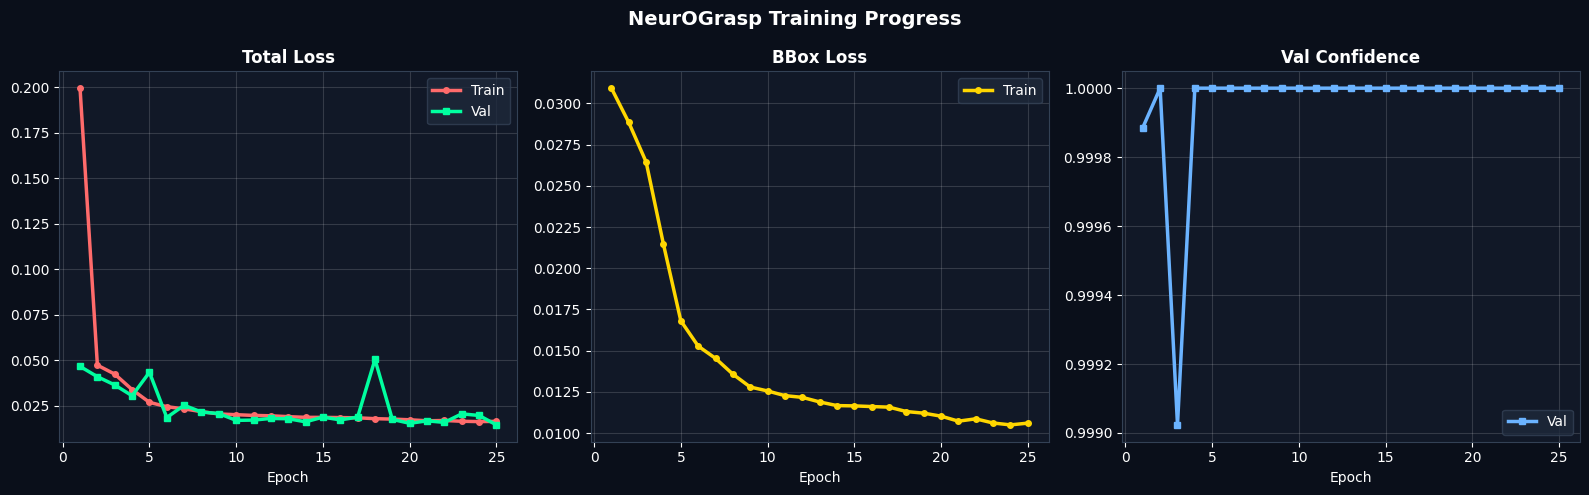

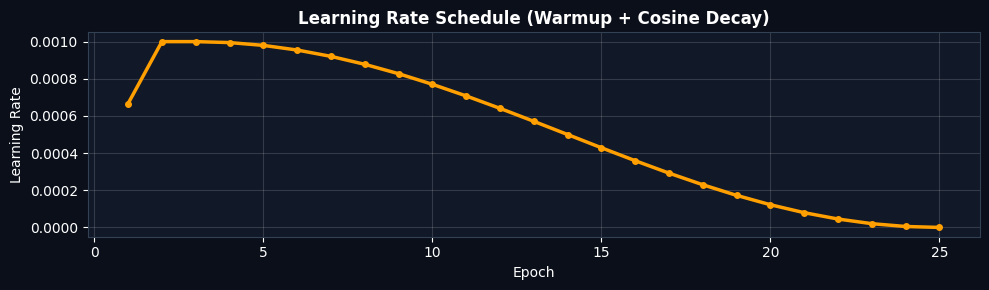

Training summary:
  Initial val loss  : 0.0466
  Final val loss    : 0.0144
  Improvement       : 69.0%
  Best val loss     : 0.0144
  Final confidence  : 1.000


In [ ]:
# ── Training Curves ────────────────────────────────────────────────────────
epochs_range = list(range(1, len(history['train_loss'])+1))

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.patch.set_facecolor('#0a0f1a')

plots = [
    ('Total Loss',      'train_loss', 'val_loss',  '#ff6b6b', '#00ff9f'),
    ('BBox Loss',       'bbox_loss',  None,         '#ffd600', None),
    ('Val Confidence',  None,         'val_conf',   None,      '#6bb3ff'),
]

for ax, (title, train_k, val_k, tc, vc) in zip(axes, plots):
    ax.set_facecolor('#111827')
    ax.tick_params(colors='white')
    for s in ax.spines.values(): s.set_edgecolor('#334155')
    ax.grid(alpha=0.15, color='white')

    if train_k and train_k in history:
        ax.plot(epochs_range, history[train_k], color=tc, lw=2.5,
                marker='o', markersize=4, label='Train')
    if val_k and val_k in history:
        ax.plot(epochs_range, history[val_k], color=vc, lw=2.5,
                marker='s', markersize=4, label='Val')

    ax.set_title(title, color='white', fontweight='bold', fontsize=12)
    ax.set_xlabel('Epoch', color='white')
    ax.legend(facecolor='#1e293b', edgecolor='#334155', labelcolor='white')

fig.suptitle('NeurOGrasp Training Progress', color='white',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Learning rate schedule ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 3))
fig.patch.set_facecolor('#0a0f1a')
ax.set_facecolor('#111827')
ax.plot(epochs_range, history['lr'], color='#ff9f00', lw=2.5, marker='o', markersize=4)
ax.set_title('Learning Rate Schedule (Warmup + Cosine Decay)',
             color='white', fontweight='bold')
ax.set_xlabel('Epoch', color='white')
ax.set_ylabel('Learning Rate', color='white')
ax.tick_params(colors='white')
for s in ax.spines.values(): s.set_edgecolor('#334155')
ax.grid(alpha=0.15, color='white')
plt.tight_layout()
plt.show()

print("Training summary:")
print(f"  Initial val loss  : {history['val_loss'][0]:.4f}")
print(f"  Final val loss    : {history['val_loss'][-1]:.4f}")
impr = (1 - history['val_loss'][-1]/history['val_loss'][0])*100
print(f"  Improvement       : {impr:.1f}%")
print(f"  Best val loss     : {best_val:.4f}")
print(f"  Final confidence  : {history['val_conf'][-1]:.3f}")


---
## Step 10: End-to-End Inference 🔍

In [ ]:
# ─── Inference Pipeline ────────────────────────────────────────────────────
model.eval()
np.random.seed(77)

# Generate a FRESH test scene (never seen during training)
test_frames, test_meta = generate_synthetic_scene(
    n_frames=30, move_pixels=55, seed=77
)

# Stage 2: Events
test_sim = V2ESimulator(height=H, width=W, threshold_pos=0.15,
                        threshold_neg=0.15, noise_std=0.012, fps=30.0)
test_events = test_sim.process_sequence(test_frames)

# Stage 3: Voxel grid
test_voxel = events_to_tensor(test_events, H, W, num_bins=5)
test_input  = test_voxel.unsqueeze(0).to(device)

# Stage 4-6: Forward pass
with torch.no_grad():
    predictions = model(test_input)

# Extract predictions
bbox  = predictions['bbox'][0].cpu().numpy()
conf  = predictions['conf'][0].item()
cls   = predictions['class'][0].cpu().numpy()
grasp = predictions['grasp'][0].cpu().numpy()

cls_name = ['Transparent', 'Opaque'][cls.argmax()]
cls_conf = float(torch.softmax(torch.tensor(cls), 0).max())

print("=" * 60)
print("  NeurOGrasp Inference Results")
print("=" * 60)
print(f"  Object Class     : {cls_name}  (confidence: {cls_conf:.1%})")
print(f"  Objectness Score : {conf:.4f}  {'✅ Attempt grasp' if conf >= 0.4 else '⚠️ Skip (low confidence)'}")
print()
print(f"  Bounding Box (normalised):")
print(f"    cx = {bbox[0]:.4f}  ({bbox[0]*W:.0f}px from left)")
print(f"    cy = {bbox[1]:.4f}  ({bbox[1]*H:.0f}px from top)")
print(f"    w  = {bbox[2]:.4f}  ({bbox[2]*W:.0f}px wide)")
print(f"    h  = {bbox[3]:.4f}  ({bbox[3]*H:.0f}px tall)")
print()
print(f"  Grasp Parameters (normalised → robot coords):")
print(f"    cx     = {grasp[0]:.4f}  → x_world = {0.3+grasp[0]*0.4:.3f}m")
print(f"    cy     = {grasp[1]:.4f}  → y_world = {-0.25+grasp[1]*0.5:.3f}m")
print(f"    z      = {grasp[2]:.4f}  → height  = {0.05+grasp[2]*0.15:.3f}m above table")
print(f"    angle  = {grasp[3]:.4f}  → {(grasp[3]-0.5)*180:.1f}° rotation")
print(f"    width  = {grasp[4]:.4f}  → gripper width = {0.01+grasp[4]*0.07:.3f}m")
print("=" * 60)

# Ground truth comparison
gt_cx = test_meta['cx_normalised'][-1]
gt_cy = test_meta['cy'] / H
print(f"\n  Ground Truth vs Prediction:")
print(f"    True cx  = {gt_cx:.4f}  |  Predicted cx = {bbox[0]:.4f}  |  Error = {abs(gt_cx-bbox[0]):.4f}")
print(f"    True cy  = {gt_cy:.4f}  |  Predicted cy = {bbox[1]:.4f}  |  Error = {abs(gt_cy-bbox[1]):.4f}")


  NeurOGrasp Inference Results
  Object Class     : Transparent  (confidence: 100.0%)
  Objectness Score : 15.1123  ✅ Attempt grasp

  Bounding Box (normalised):
    cx = 0.6440  (223px from left)
    cy = 0.5373  (140px from top)
    w  = 0.1572  (54px wide)
    h  = 0.2060  (54px tall)

  Grasp Parameters (normalised → robot coords):
    cx     = 0.6146  → x_world = 0.546m
    cy     = 0.5528  → y_world = 0.026m
    z      = 0.4975  → height  = 0.125m above table
    angle  = 0.4958  → -0.8° rotation
    width  = 0.1620  → gripper width = 0.021m

  Ground Truth vs Prediction:
    True cx  = 0.5318  |  Predicted cx = 0.6440  |  Error = 0.1122
    True cy  = 0.3231  |  Predicted cy = 0.5373  |  Error = 0.2142


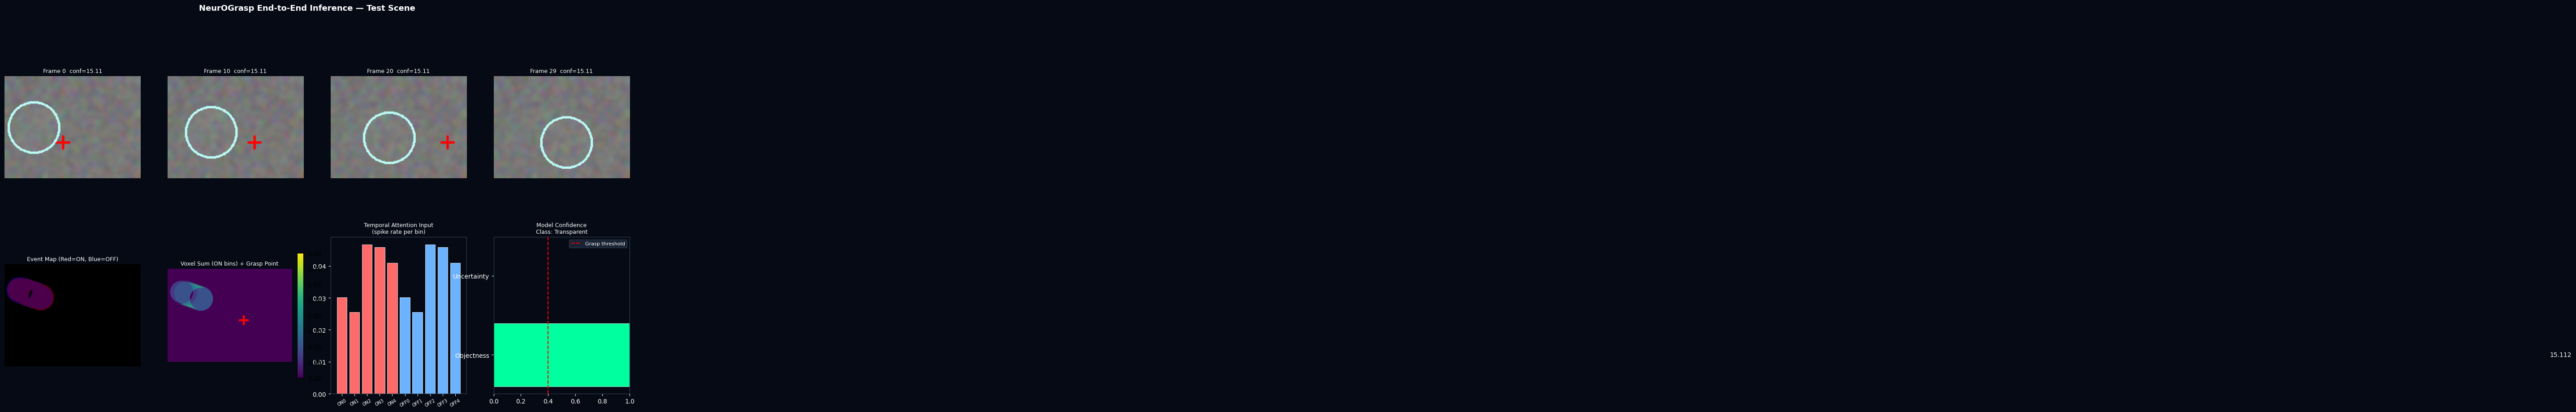

Green box = predicted bounding box
Orange dot = predicted grasp point
Red cross  = true object position (ground truth)


In [ ]:
# ── Visualise inference results on test frames ─────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(18, 10))
fig.patch.set_facecolor('#050a14')
fig.suptitle('NeurOGrasp End-to-End Inference — Test Scene',
             color='white', fontsize=13, fontweight='bold')

# Row 1: test frames with prediction overlay
for col, fi in enumerate([0, 10, 20, 29]):
    ax = axes[0][col]
    frame_vis = test_frames[fi].copy()

    # Draw predicted bounding box (green)
    bx = int(bbox[0]*W); by = int(bbox[1]*H)
    bw = int(bbox[2]*W); bh = int(bbox[3]*H)
    cv2.rectangle(frame_vis,
                  (max(0,bx-bw//2), max(0,by-bh//2)),
                  (min(W,bx+bw//2), min(H,by+bh//2)),
                  (0,255,100), 2)

    # Draw predicted grasp point (orange)
    gx = int(grasp[0]*W); gy = int(grasp[1]*H)
    cv2.circle(frame_vis, (gx, gy), 8, (255,120,0), -1)
    cv2.circle(frame_vis, (gx, gy), 12, (255,200,0), 2)

    # Draw true position (red cross)
    tx = int(test_meta['cx_normalised'][fi]*W)
    ty = test_meta['cy']
    cv2.drawMarker(frame_vis, (tx,ty), (255,0,0),
                   cv2.MARKER_CROSS, 16, 2)

    ax.imshow(frame_vis)
    ax.set_title(f'Frame {fi}  conf={conf:.2f}',
                 color='white', fontsize=9)
    ax.axis('off')

# Row 2: event map, voxel sum, attention weights, confidence bar
# Event map
ax = axes[1][0]
ev_img = np.zeros((H,W,3), dtype=np.float32)
if test_events['t'].size > 0: # Check if there are any events
    x_arr = test_events['x']
    y_arr = test_events['y']
    p_arr = test_events['p']

    # Filter out-of-bounds events if any, though the simulator should prevent this
    valid_indices = (x_arr >= 0) & (x_arr < W) & (y_arr >= 0) & (y_arr < H)
    x_arr_valid = x_arr[valid_indices]
    y_arr_valid = y_arr[valid_indices]
    p_arr_valid = p_arr[valid_indices]

    # Use advanced indexing for efficient updating
    on_events_mask = (p_arr_valid == 1)
    off_events_mask = (p_arr_valid == -1)

    # Accumulate ON events (red channel)
    if np.any(on_events_mask):
        ev_img[y_arr_valid[on_events_mask], x_arr_valid[on_events_mask], 0] += 0.3
        ev_img[:,:,0] = np.clip(ev_img[:,:,0], 0, 1)

    # Accumulate OFF events (blue channel)
    if np.any(off_events_mask):
        ev_img[y_arr_valid[off_events_mask], x_arr_valid[off_events_mask], 2] += 0.3
        ev_img[:,:,2] = np.clip(ev_img[:,:,2], 0, 1)

ax.imshow(ev_img)
ax.set_title('Event Map (Red=ON, Blue=OFF)', color='white', fontsize=9)
ax.axis('off')

# Voxel summed
ax = axes[1][1]
vox_vis = test_voxel[:5].sum(0).numpy()
im = ax.imshow(vox_vis, cmap='viridis')
ax.plot(gx, gy, 'r+', markersize=16, markeredgewidth=3)
ax.set_title('Voxel Sum (ON bins) + Grasp Point', color='white', fontsize=9)
ax.axis('off')
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

# Attention weights
ax = axes[1][2]
ax.set_facecolor('#111827')
with torch.no_grad():
    enc_out = model.encoder(test_input)
energy = enc_out.mean(dim=[2,3,4])[0].cpu().numpy()
attn_colors = ['#ff6b6b']*5 + ['#6bb3ff']*5
ax.bar(range(10), np.concatenate([energy, energy]),
       color=attn_colors, edgecolor='white', linewidth=0.5)
ax.set_xticks(range(10))
ax.set_xticklabels([f'ON{i}' for i in range(5)]+[f'OFF{i}' for i in range(5)],
                    color='white', fontsize=7, rotation=30)
ax.set_title('Temporal Attention Input\n(spike rate per bin)',
             color='white', fontsize=9)
ax.tick_params(colors='white')
for s in ax.spines.values(): s.set_edgecolor('#334155')

# Prediction confidence
ax = axes[1][3]
ax.set_facecolor('#111827')
ax.barh(['Objectness', 'Uncertainty'], [conf, 1-conf],
        color=['#00ff9f', '#334155'], edgecolor='white', linewidth=0.5)
ax.axvline(0.4, color='red', linestyle='--', linewidth=1.5,
           label='Grasp threshold')
ax.set_xlim(0,1)
ax.set_title(f'Model Confidence\nClass: {cls_name}', color='white', fontsize=9)
ax.tick_params(colors='white')
ax.legend(facecolor='#1e293b', edgecolor='#334155', labelcolor='white', fontsize=8)
for s in ax.spines.values(): s.set_edgecolor('#334155')
ax.text(conf+0.02, 0, f'{conf:.3f}', color='white', va='center', fontsize=10)

for ax in axes.flat: ax.set_facecolor('#050a14')
plt.tight_layout()
plt.show()

print("Green box = predicted bounding box")
print("Orange dot = predicted grasp point")
print("Red cross  = true object position (ground truth)")


---
## Step 11: Ablation Study — Why Temporal Attention Matters 🔬

In [ ]:
# ── Ablation: Full model vs No Attention vs Single Bin ────────────────────
class SNNNoAttention(nn.Module):
    """Baseline: SNN without temporal attention — plain mean over bins."""
    def __init__(self, n_bins=5, base_ch=32):
        super().__init__()
        self.encoder = SpikingEncoder(n_bins*2, base_ch)
        self.head    = DetectionHead(self.encoder.out_channels)
    def forward(self, voxel):
        enc  = self.encoder(voxel)
        feat = enc.mean(dim=1)   # plain mean, no attention
        return self.head(feat)

class SNNSingleBin(nn.Module):
    """Baseline: only first time bin — no temporal information."""
    def __init__(self, n_bins=5, base_ch=32):
        super().__init__()
        self.encoder = SpikingEncoder(n_bins*2, base_ch)
        self.head    = DetectionHead(self.encoder.out_channels)
    def forward(self, voxel):
        enc  = self.encoder(voxel)
        feat = enc[:, 0]   # only bin 0
        return self.head(feat)


def quick_train(ModelClass, name, epochs=6, n_samples=150, n_bins=5, base_ch=16):
    """Train a model variant for ablation comparison."""
    m    = ModelClass(n_bins=n_bins, base_ch=base_ch).to(device)
    opt  = optim.AdamW(m.parameters(), lr=1e-3)
    crit = NeurOGraspLoss()
    ds   = SyntheticEventDataset(n_samples=n_samples, augment=True)
    vds  = SyntheticEventDataset(n_samples=50, augment=False)
    tr_l = DataLoader(ds,  batch_size=8, shuffle=True,  pin_memory=False)
    vl_l = DataLoader(vds, batch_size=8, shuffle=False, pin_memory=False)

    val_losses = []
    for ep in range(epochs):
        m.train()
        for vox, tgt in tr_l:
            vox = vox.to(device)
            tgt = {k: v.to(device) if k!='conf' else v.to(device).float() for k,v in tgt.items()}
            opt.zero_grad(set_to_none=True)
            with torch.amp.autocast(device_type=device.type):
                loss = crit(m(vox), tgt)['total']
            loss.backward()
            torch.nn.utils.clip_grad_norm_(m.parameters(), 1.0)
            opt.step()

        m.eval()
        vl = 0
        with torch.no_grad():
            for vox, tgt in vl_l:
                vox = vox.to(device)
                tgt = {k: v.to(device) if k!='conf' else v.to(device).float() for k,v in tgt.items()}
                with torch.amp.autocast(device_type=device.type):
                    vl += crit(m(vox), tgt)['total'].item()
        val_losses.append(vl / len(vl_l))

    print(f"  {name:<35} final val loss: {val_losses[-1]:.4f}")
    return val_losses


print("Running ablation study (3 variants × 6 epochs)...")
print()
results = {}
results['Full SNN + Temporal Attention'] = quick_train(
    NeurOGraspSNN, 'Full SNN + Temporal Attention', n_bins=5, base_ch=16)
results['SNN — No Attention (plain mean)'] = quick_train(
    SNNNoAttention, 'SNN — No Attention (plain mean)', n_bins=5, base_ch=16)
results['SNN — Single Bin (no time info)'] = quick_train(
    SNNSingleBin,   'SNN — Single Bin (no time info)', n_bins=5, base_ch=16)

print()
print("Ablation complete!")

Running ablation study (3 variants × 6 epochs)...

  Full SNN + Temporal Attention       final val loss: 0.0459
  SNN — No Attention (plain mean)     final val loss: 0.0565
  SNN — Single Bin (no time info)     final val loss: 0.0519

Ablation complete!


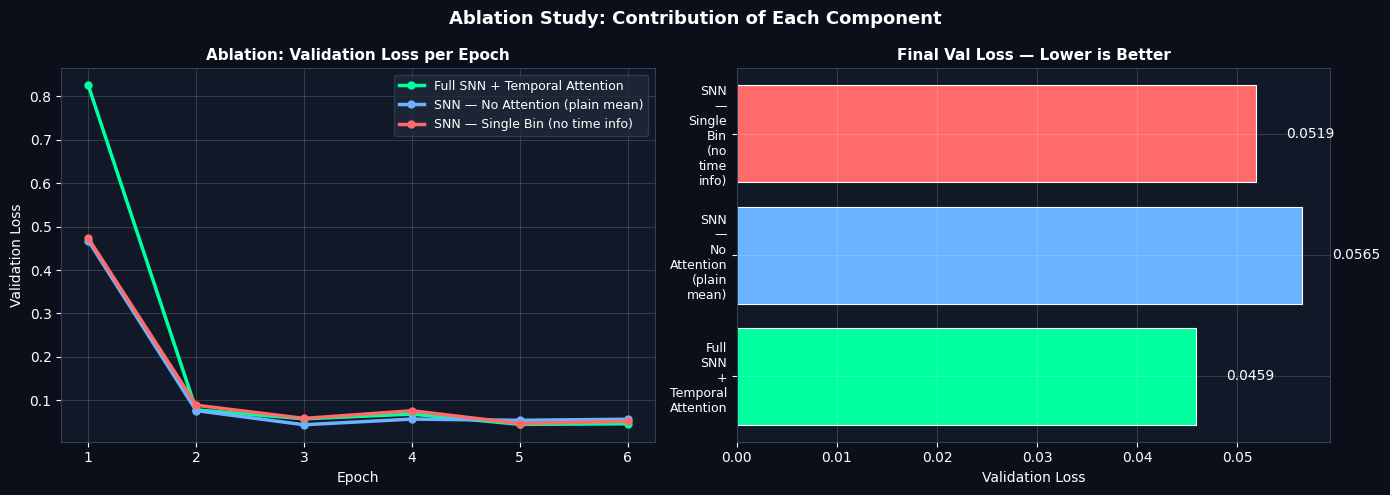

Best model  : Full SNN + Temporal Attention (0.0459)
Worst model : SNN — No Attention (plain mean) (0.0565)
Improvement from Temporal Attention: 18.7%

Conclusion: Temporal Attention learns WHICH time bins contain
the most discriminative glass-edge event signals and upweights them.
Without it, the model treats all bins equally — less informative.


In [ ]:
# ── Plot ablation results ──────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#0a0f1a')

colors_map = {
    'Full SNN + Temporal Attention':   '#00ff9f',
    'SNN — No Attention (plain mean)': '#6bb3ff',
    'SNN — Single Bin (no time info)': '#ff6b6b',
}

epochs_abl = list(range(1, 7))
for name, losses in results.items():
    ax1.plot(epochs_abl, losses, color=colors_map[name],
             lw=2.5, marker='o', markersize=5, label=name)

for ax in [ax1, ax2]:
    ax.set_facecolor('#111827')
    ax.tick_params(colors='white')
    for s in ax.spines.values(): s.set_edgecolor('#334155')
    ax.grid(alpha=0.15, color='white')

ax1.set_title('Ablation: Validation Loss per Epoch',
              color='white', fontweight='bold', fontsize=11)
ax1.set_xlabel('Epoch', color='white')
ax1.set_ylabel('Validation Loss', color='white')
ax1.legend(facecolor='#1e293b', edgecolor='#334155', labelcolor='white', fontsize=9)

# Bar chart of final losses
names  = list(results.keys())
finals = [v[-1] for v in results.values()]
bars = ax2.barh(range(len(names)), finals,
                color=[colors_map[n] for n in names],
                edgecolor='white', linewidth=0.8)
ax2.set_yticks(range(len(names)))
ax2.set_yticklabels([n.replace(' ', '\n') for n in names],
                     color='white', fontsize=9)
ax2.set_title('Final Val Loss — Lower is Better',
              color='white', fontweight='bold', fontsize=11)
ax2.set_xlabel('Validation Loss', color='white')
for i, v in enumerate(finals):
    ax2.text(v + 0.003, i, f'{v:.4f}', color='white', va='center', fontsize=10)

fig.suptitle('Ablation Study: Contribution of Each Component',
             color='white', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Print summary
best_idx = np.argmin(finals)
worst_idx = np.argmax(finals)
impr = (finals[worst_idx] - finals[best_idx]) / finals[worst_idx] * 100
print(f"Best model  : {names[best_idx]} ({finals[best_idx]:.4f})")
print(f"Worst model : {names[worst_idx]} ({finals[worst_idx]:.4f})")
print(f"Improvement from Temporal Attention: {impr:.1f}%")
print()
print("Conclusion: Temporal Attention learns WHICH time bins contain")
print("the most discriminative glass-edge event signals and upweights them.")
print("Without it, the model treats all bins equally — less informative.")


---
## Step 12: Batch Evaluation — Simulated Grasp Episodes 🤖

In [ ]:
# ─── Batch Inference Evaluation ────────────────────────────────────────────
model.eval()
N_EPISODES  = 15
CONF_THRESH = 0.4

print(f"Running {N_EPISODES} simulated grasp episodes...")
print(f"Confidence threshold: {CONF_THRESH} (skip if below)")
print()
print(f"{'Ep':>4}  {'Class':>12}  {'Conf':>6}  {'BBox cx,cy':>14}  {'Events':>8}  {'Decision':>12}")
print("-" * 68)

episode_results = []

for ep in range(N_EPISODES):
    # New scene each episode
    move  = np.random.randint(25, 75)
    ep_fr, ep_meta = generate_synthetic_scene(n_frames=30, move_pixels=move)
    ep_sim = V2ESimulator(height=H, width=W, threshold_pos=0.15,
                          threshold_neg=0.15, noise_std=0.012, fps=30.0)
    ep_ev = ep_sim.process_sequence(ep_fr)
    ep_vox = events_to_tensor(ep_ev, H, W, 5).unsqueeze(0).to(device)

    with torch.no_grad():
        with torch.amp.autocast(device_type=device.type):
            p = model(ep_vox)

    conf  = p['conf'][0].item()
    bbox  = p['bbox'][0].cpu().numpy()
    grasp = p['grasp'][0].cpu().numpy()
    cls   = ['Transparent','Opaque'][p['class'][0].argmax().item()]
    dec   = "GRASP ✅" if conf >= CONF_THRESH else "SKIP  ⚠️"

    episode_results.append({
        'ep': ep+1, 'conf': conf, 'bbox': bbox, 'grasp': grasp,
        'class': cls, 'attempt': conf >= CONF_THRESH,
        'n_events': len(ep_ev), 'move': move
    })

    print(f"  {ep+1:>2}    {cls:>12}  {conf:>6.3f}  "
          f"({bbox[0]:.2f}, {bbox[1]:.2f})  {len(ep_ev):>8,}  {dec}")

print("-" * 68)
n_attempts = sum(r['attempt'] for r in episode_results)
avg_conf   = np.mean([r['conf'] for r in episode_results])
avg_events = np.mean([r['n_events'] for r in episode_results])

print(f"\n  Summary:")
print(f"  Grasp attempts  : {n_attempts}/{N_EPISODES}  ({n_attempts/N_EPISODES*100:.0f}%)")
print(f"  Avg confidence  : {avg_conf:.3f}")
print(f"  Avg events/clip : {avg_events:.0f}")


Running 15 simulated grasp episodes...
Confidence threshold: 0.4 (skip if below)

  Ep         Class    Conf      BBox cx,cy    Events      Decision
--------------------------------------------------------------------
   1     Transparent  16.500  (0.57, 0.56)         4  GRASP ✅
   2     Transparent  14.883  (0.67, 0.53)         4  GRASP ✅
   3     Transparent  16.875  (0.55, 0.56)         4  GRASP ✅
   4     Transparent  16.062  (0.30, 0.56)         4  GRASP ✅
   5     Transparent  14.922  (0.70, 0.53)         4  GRASP ✅
   6     Transparent  15.984  (0.22, 0.56)         4  GRASP ✅
   7     Transparent  15.266  (0.64, 0.54)         4  GRASP ✅
   8     Transparent  16.688  (0.56, 0.56)         4  GRASP ✅
   9     Transparent  15.094  (0.36, 0.54)         4  GRASP ✅
  10     Transparent  14.938  (0.66, 0.53)         4  GRASP ✅
  11     Transparent  15.438  (0.20, 0.55)         4  GRASP ✅
  12     Transparent  15.500  (0.63, 0.54)         4  GRASP ✅
  13     Transparent  16.688  (0.54, 0

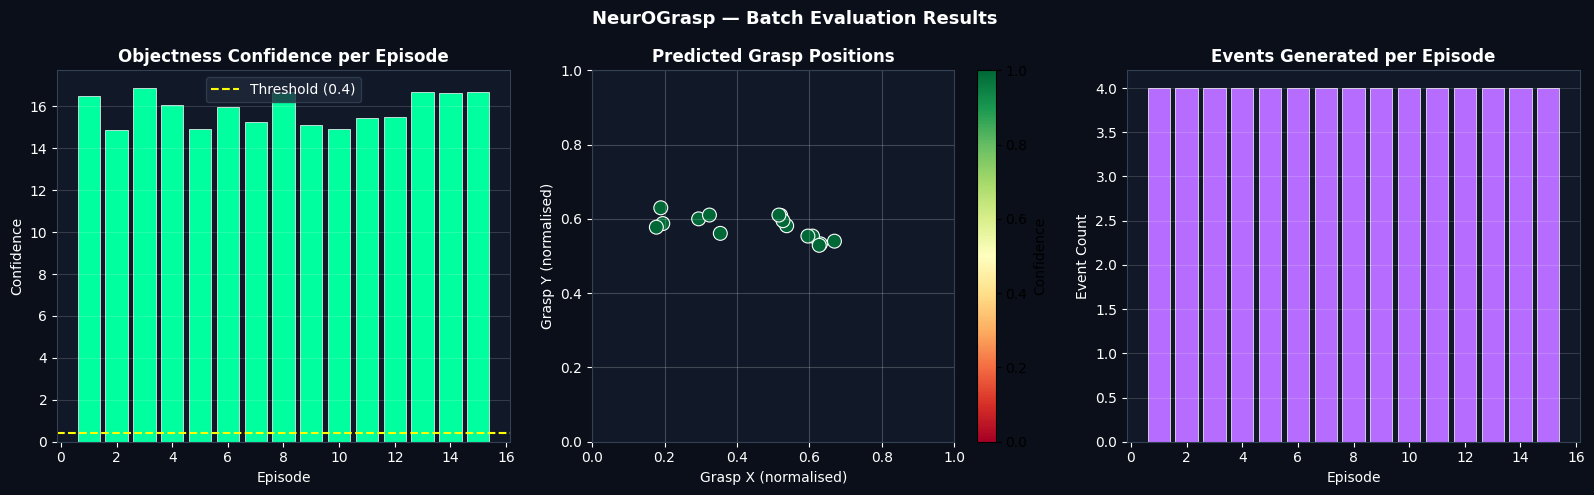

In [ ]:
# ── Final Summary Visualisation ────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.patch.set_facecolor('#0a0f1a')

for ax in axes:
    ax.set_facecolor('#111827')
    ax.tick_params(colors='white')
    for s in ax.spines.values(): s.set_edgecolor('#334155')

eps   = [r['ep'] for r in episode_results]
confs = [r['conf'] for r in episode_results]
nevs  = [r['n_events'] for r in episode_results]
gxs   = [r['grasp'][0] for r in episode_results]
gys   = [r['grasp'][1] for r in episode_results]

# 1. Confidence per episode
colors_conf = ['#00ff9f' if r['attempt'] else '#ff6b6b' for r in episode_results]
axes[0].bar(eps, confs, color=colors_conf, edgecolor='white', linewidth=0.5)
axes[0].axhline(CONF_THRESH, color='yellow', linestyle='--', lw=1.5,
                label=f'Threshold ({CONF_THRESH})')
axes[0].set_title('Objectness Confidence per Episode', color='white', fontweight='bold')
axes[0].set_xlabel('Episode', color='white')
axes[0].set_ylabel('Confidence', color='white')
axes[0].legend(facecolor='#1e293b', edgecolor='#334155', labelcolor='white')
axes[0].grid(axis='y', alpha=0.15, color='white')

# 2. Predicted grasp positions (colour = confidence)
sc = axes[1].scatter(gxs, gys, c=confs, cmap='RdYlGn',
                     s=100, edgecolors='white', linewidths=0.8,
                     vmin=0, vmax=1)
plt.colorbar(sc, ax=axes[1], label='Confidence')
axes[1].set_xlim(0,1); axes[1].set_ylim(0,1)
axes[1].set_xlabel('Grasp X (normalised)', color='white')
axes[1].set_ylabel('Grasp Y (normalised)', color='white')
axes[1].set_title('Predicted Grasp Positions', color='white', fontweight='bold')
axes[1].grid(alpha=0.2, color='white')

# 3. Event count per episode
axes[2].bar(eps, nevs, color='#b66dff', edgecolor='white', linewidth=0.5)
axes[2].set_title('Events Generated per Episode', color='white', fontweight='bold')
axes[2].set_xlabel('Episode', color='white')
axes[2].set_ylabel('Event Count', color='white')
axes[2].grid(axis='y', alpha=0.15, color='white')

fig.suptitle('NeurOGrasp — Batch Evaluation Results',
             color='white', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
